# MMMU-Pro Eval300 × Gemma 4 26B A4B IT
## P1 step-by-step explanation

This notebook evaluates all **300 IDs** of the project's frozen ordered
MMMU-Pro selection. It is the production version selected after the paired
First50 prompt pilot. The prompt asks for visible reasoning without imposing
the additional word `briefly`.

The model configuration remains: `temperature=0.0`, `seed=42`,
`max_tokens=8192`, `stream=false`, no `top_p`, no `top_k`, and
`thinkingLevel="minimal"`.

### Exact per-item model input

```text
[images first, in `<image n>` marker-occurrence order]
[repeated image references repeat the corresponding image block]

{question with every numbered image marker normalized to `<image>`}

A. ...
B. ...
...
{LAST_AVAILABLE_LETTER}. ...

Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Think step by step before answering.
Explain your reasoning before answering.
```

There is no added `Question:` prefix. Scoring uses a frozen, deterministic,
gold-blind final-line answer parser. Harmless wrappers (`B`, `$B`, `$B$`,
or `(B)`) are accepted only on the last non-empty line; exact compliance
with the instantiated requested form (for example, `Answer: B`) is reported
separately. Here `$LETTER` in the prompt is treated as a placeholder. There is
no random fallback and truncated responses remain unparsed and incorrect.
The main timeout is 1,800 seconds;
per-item request failures are retained and retried after the main pass with a
7,200-second timeout. Valid model responses—including parse failures and
length-limited generations—are checkpointed once and never selectively
regenerated. Compatible prior outputs are resumed by exact experiment
signature, so only IDs without a valid provider response are sent again.


## Frozen Eval300 reconstruction from an ordered ID list

The evaluation cohort is reconstructed from the official Hugging Face source:

```text
MMMU/MMMU_Pro / standard (10 options) / test
```

at the exact immutable source revision:

```text
563f3e84bb3b90893083a1f039cfa13077f2302b
```

The notebook first downloads all 1,730 rows in this source setting and then
performs exact ID lookup using `selected_ids.txt`. There is no re-sampling,
nearest-match lookup, question-text matching, or subject-based replacement.

The line order of `selected_ids.txt` is the evaluation order. Candidate options
are preserved row-faithfully:

- answer letters are derived dynamically from each row's actual option count;
- every option is preserved exactly as published;
- no option is padded, truncated, invented, or rewritten;
- every gold label must be valid for the row's actual choice set;
- the selected option-count distribution is archived.

Because the inference notebook receives only the frozen ID list (not the
few-shot pool), it does **not** claim to independently recompute few-shot
disjointness. That property belongs to the upstream dataset-construction stage.
This notebook instead proves that it evaluates the exact cryptographically
pinned ID list produced by that stage.


## Fixed generation / reproducibility protocol

Every benchmark request uses:

```text
temperature          = 0.0
top_p                 = not sent
top_k                 = not sent
max_tokens            = 8192
seed                  = 42
stream                = false
enable_thinking       = false
reasoning_budget      = not sent
```

The hosted Google endpoint supports a fixed request seed. The notebook archives
the exact endpoint, model name, payload policy, prompt hashes, ordered-ID hash,
decoding settings, and reasoning-control fields in the experiment signature.

A P1-visible explanation is ordinary response content requested by the prompt;
it is not provider-native hidden/thinking mode.


# 0. Kaggle resume protocol

Required:
1. the frozen `selected_ids.txt`;
2. Kaggle Internet enabled;
3. a Kaggle Secret named `GOOGLE_API_KEY` (or `GEMINI_API_KEY`).

No GPU and no local model files are required.

Each valid provider response is checkpointed immediately. If the Google free
endpoint rate/quota is exhausted, save the Kaggle Version, attach its output in
the next run, and rerun. Resume is allowed only when the exact experiment
signature matches. If several compatible prior versions are attached, the
notebook chooses the one with the largest validated set of successful IDs.
Attach the **entire prior Kaggle output**, not only `results_all.csv`; automatic
production resume requires both `run_manifest.json` and `raw_results.jsonl`.
The older nonbrief First50 pilot can also be seeded from its
`raw_results*.jsonl`, but only through the separate record-equivalence gate.
The earlier First50 output from the **same nonbrief condition** may be migrated
only after complete record-level equivalence checks. The `briefly` condition,
another model, or any changed payload is rejected automatically.


# 1. Install only missing benchmark dependencies

Inference uses Python `requests` directly against Google's hosted Gemini Developer API
`generateContent` endpoint. No OpenAI/Google SDK and no model weights are
needed.

The official pinned MMMU-Pro parquet source is downloaded later only for exact
Eval300 reconstruction.


In [1]:
import importlib.util, subprocess, sys

requirements = {
    "datasets": "datasets>=3.0",
    "huggingface_hub": "huggingface_hub>=0.24",
    "requests": "requests>=2.31",
    "sklearn": "scikit-learn>=1.3",
    "statsmodels": "statsmodels>=0.14",
    "PIL": "Pillow>=10",
    "pandas": "pandas>=2",
    "numpy": "numpy>=1.26",
    "matplotlib": "matplotlib>=3.8",
}

to_install = [
    spec for mod, spec in requirements.items()
    if importlib.util.find_spec(mod) is None
]

if to_install:
    print("Installing missing packages:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *to_install]
    )
else:
    print("All required packages already available.")

print("Inference client: requests (direct Google Gemini REST call)")
print("No model weights are downloaded.")


All required packages already available.
Inference client: requests (direct Google Gemini REST call)
No model weights are downloaded.


# 2. Frozen experimental configuration

## Final generation protocol

```text
Model endpoint     = gemma-4-26b-a4b-it
Provider           = Google Gemini Developer API / Gemma 4 Free Tier
HTTP endpoint      = https://generativelanguage.googleapis.com/v1beta/models/gemma-4-26b-a4b-it:generateContent
Temperature        = 0.0
Top-p              = not sent
Top-k              = not sent
Max output tokens  = 8192
Request seed       = 42
Streaming          = false
Native reasoning   = OFF
Reasoning budget   = not sent
Reasoning control  = thinkingLevel="minimal"
Image transport    = lossless PNG base64 inlineData, images first
```

The hosted endpoint has provider-managed context. We do not claim a local
`ctx-size` setting.

### Evaluation-source protocol

```text
ID input           = selected_ids.txt
ID cohort          = all 300 IDs of the exact frozen ordered list
Source             = MMMU/MMMU_Pro
Setting            = standard (10 options)
Split              = test
Source rows        = exactly 1,730
Revision           = 563f3e84bb3b90893083a1f039cfa13077f2302b
Selection          = exact ID lookup preserving selected_ids.txt order
```


In [2]:
import os, io, re, ast, json, time, math, base64, random, string, shutil
import hashlib, html, platform, subprocess, sys, shlex, threading, logging, importlib.metadata
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset, Image as HFImage
from huggingface_hub import snapshot_download
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix,
)
from statsmodels.stats.proportion import proportion_confint

EXPERIMENT_ID = 'MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-ExplanationBaseline-WithoutBriefly__GoogleGeminiAPIFreeTier__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temp0__Seed42__MAX8192'
PROMPT_ID = 'P0-ExplanationBaseline-WithoutBriefly'
PROMPT_FAMILY = 'Zero-shot visible-explanation baseline'
EVALUATION_COHORT_ID = 'MMMUPro-frozen-balanced-eval300-v1'

MODEL = "gemma-4-26b-a4b-it"
BASE_MODEL = "Gemma 4 26B A4B IT"
MODEL_ARCHITECTURE = "26B-A4B multimodal MoE reasoning-capable"

PROVIDER = "Google Gemini Developer API / Gemma 4 Free Tier"
API_METHOD = "requests POST /v1beta/models/{model}:generateContent"
API_MODE = "hosted stateless Gemini GenerateContent REST API"
API_VERSION = "v1beta"
INVOKE_URL = "https://generativelanguage.googleapis.com/v1beta/models/gemma-4-26b-a4b-it:generateContent"
STATUS_URL_TEMPLATE = None
FREE_TIER_POLICY = "Google Gemini Developer API Gemma 4 Free Tier; input/output are free of charge; quotas are provider-controlled"

DATASET_REPO = "MMMU/MMMU_Pro"
DATASET_CONFIG = "standard (10 options)"
DATASET_SUBDIR = "standard (10 options)"
DATASET_SPLIT = "test"
DATASET_REVISION = "563f3e84bb3b90893083a1f039cfa13077f2302b"
REVISION_SOURCE = "hard-pinned full Hugging Face commit SHA"
EXPECTED_SOURCE_N = 1730
EXPECTED_FULL_SELECTION_N = 300
EXPECTED_N = 300

EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION = {
    2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12,
    8: 31, 9: 221, 10: 1213, 12: 1,
}

SELECTION_PROTOCOL_NAME = (
    "all 300 IDs of the frozen ordered selected_ids.txt; exact ID "
    "extraction from the pinned official MMMU-Pro source; no resampling"
)
EXPECTED_FULL_SELECTED_IDS_CANONICAL_SHA256 = 'db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3'
EXPECTED_SELECTED_IDS_CANONICAL_SHA256 = EXPECTED_FULL_SELECTED_IDS_CANONICAL_SHA256
LEGACY_FIRST50_IDS_CANONICAL_SHA256 = 'e6482ced291020e4a41f5cfa8648a0b384f47029094a27119eb28f820802a58b'
LEGACY_FIRST50_EXPERIMENT_ID = 'MMMUPro-First50__Gemma4-26B-A4B-IT__P0-Without-Briefly__GoogleGeminiAPIFreeTier__PairedPromptComparison__ImageOrderFix__LongDeferredTimeout__Temp0__Seed42__MAX8192'
LEGACY_FIRST50_PROMPT_ID = 'P0-Original-First50'
LEGACY_FIRST50_PROMPT_FAMILY = 'Explanation Baseline — First50 paired pilot'
ALLOW_VALIDATED_FIRST50_MIGRATION = True

INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    raise RuntimeError("/kaggle/input is missing; this notebook is intended for Kaggle.")


def canonical_id_text(ids):
    return "\n".join(ids) + "\n"


def canonical_id_sha256(ids):
    return hashlib.sha256(canonical_id_text(ids).encode("utf-8")).hexdigest()


def read_id_file_strict(path):
    text = Path(path).read_text(encoding="utf-8")
    lines = text.splitlines()
    if any((not line) or line != line.strip() for line in lines):
        raise RuntimeError(
            f"ID file contains blank lines or surrounding whitespace: {path}"
        )
    return lines, hashlib.sha256(Path(path).read_bytes()).hexdigest()


# Resolve the exact frozen 300-ID evaluation file.
all_selected_id_files = sorted({
    p.resolve()
    for p in INPUT_ROOT.rglob("selected_ids.txt")
    if p.is_file()
})

matching_id_files = []
id_file_diagnostics = []
for p in all_selected_id_files:
    try:
        ids_here, raw_sha_here = read_id_file_strict(p)
        canonical_sha_here = canonical_id_sha256(ids_here)
        id_file_diagnostics.append({
            "path": str(p),
            "rows": len(ids_here),
            "unique_rows": len(set(ids_here)),
            "raw_sha256": raw_sha_here,
            "canonical_sha256": canonical_sha_here,
        })
        if canonical_sha_here == EXPECTED_FULL_SELECTED_IDS_CANONICAL_SHA256:
            matching_id_files.append((p, ids_here, raw_sha_here))
    except Exception as e:
        id_file_diagnostics.append({"path": str(p), "error": repr(e)})

if not matching_id_files:
    raise RuntimeError(
        "No uploaded selected_ids.txt matches the frozen 300-ID source list.\n"
        f"Expected full-list canonical SHA256: "
        f"{EXPECTED_FULL_SELECTED_IDS_CANONICAL_SHA256}\n"
        f"Discovered files: {json.dumps(id_file_diagnostics, ensure_ascii=False, indent=2)}"
    )

matching_id_files.sort(key=lambda x: str(x[0]))
SELECTED_IDS_PATH, full_selected_ids, SELECTED_IDS_RAW_SHA256 = matching_id_files[0]
FULL_SELECTED_IDS_CANONICAL_SHA256 = canonical_id_sha256(full_selected_ids)

if len(full_selected_ids) != EXPECTED_FULL_SELECTION_N:
    raise RuntimeError(
        f"Full selected_ids.txt rows={len(full_selected_ids)} "
        f"!= {EXPECTED_FULL_SELECTION_N}"
    )
if len(set(full_selected_ids)) != EXPECTED_FULL_SELECTION_N:
    raise RuntimeError("Full selected_ids.txt contains duplicate IDs.")

selected_ids = list(full_selected_ids)
SELECTED_IDS_CANONICAL_SHA256 = canonical_id_sha256(selected_ids)
if len(selected_ids) != EXPECTED_N or len(set(selected_ids)) != EXPECTED_N:
    raise RuntimeError("Eval300 selection is not exactly 300 unique IDs.")
if SELECTED_IDS_CANONICAL_SHA256 != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError("Eval300 selected-ID canonical hash mismatch.")
if canonical_id_sha256(selected_ids[:50]) != LEGACY_FIRST50_IDS_CANONICAL_SHA256:
    raise RuntimeError("The frozen Eval300 First50 prefix hash has changed.")

_id_pattern = re.compile(r"^(test|validation)_(.+)_([0-9]+)$")
id_subject_tokens = []
for sid in selected_ids:
    m = _id_pattern.fullmatch(sid)
    if not m:
        raise RuntimeError(f"Unexpected MMMU ID format: {sid!r}")
    id_subject_tokens.append(m.group(2))
id_subject_counts = Counter(id_subject_tokens)
if sum(id_subject_counts.values()) != EXPECTED_N:
    raise RuntimeError("Eval300 subject-count audit mismatch.")
if len(id_subject_counts) != 30 or set(id_subject_counts.values()) != {10}:
    raise RuntimeError(
        "Eval300 is not balanced at exactly 10 items for each of 30 subjects: "
        f"{dict(sorted(id_subject_counts.items()))}"
    )

API_SEED = 42
SEED_POLICY = "fixed_seed_all_requests_v1"

PROTOCOL_VERSION = 'P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V2_IMAGEORDER_VALIDATED_RESUME_LONGDEFER_MAX8192'
PARSER_VERSION = 'deterministic_final_line_answer_v1'
LOGGING_VERSION = "google_gemini_api_live_per_request_full_error_v3"
SCHEDULING_VERSION = "google_free_preflight_defer_retry_longtimeout_resume_v3"
IMAGE_ENCODING_POLICY = "lossless_png_google_inline_data_v2"
IMAGE_ORDER_POLICY = "MMMU-Pro marker occurrence order; repeated references preserved; markers normalized"

TEMPERATURE = 0.0
TOP_P = None
TOP_K = None
MAX_TOKENS = 8192
STREAM = False
NATIVE_THINKING = False
ENABLE_THINKING = False
REASONING_BUDGET = None
REQUEST_SEED = API_SEED

CTX_SIZE = None
CTX_SIZE_POLICY = "provider managed; no explicit local context-size parameter"

assert TEMPERATURE == 0.0
assert TOP_P is None
assert TOP_K is None
assert API_SEED == 42
assert MAX_TOKENS == 8192
assert NATIVE_THINKING is False
assert ENABLE_THINKING is False
assert REASONING_BUDGET is None
assert PARSER_VERSION == 'deterministic_final_line_answer_v1'

REQUEST_TIMEOUT_S = 1800
DEFERRED_REQUEST_TIMEOUT_S = 7200
MAX_ATTEMPTS = 3
DEFERRED_MAX_ATTEMPTS = 3
BASE_BACKOFF_S = 15.0
MAX_BACKOFF_S = 90.0
INTER_REQUEST_DELAY_S = 5.0
RETRYABLE_STATUS = {408, 409, 425, 429, 500, 502, 503, 504}
DEFERRED_RETRY_PASSES = 1
MAX_CONSECUTIVE_EXHAUSTED_429 = 2
ASYNC_POLL_INTERVAL_S = 2.0
SOFT_WALLCLOCK_HOURS = 10.5

ARCHIVE_IMAGES = True
GENERATE_HTML_AUDIT = True
N_BOOTSTRAP = 2000
PRICE_INPUT_PER_1M_USD = None
PRICE_OUTPUT_PER_1M_USD = None

WORKDIR = Path('/kaggle/working/gemma4-26b-a4b-it_eval300_without_briefly_v2')
MEDIA_DIR = WORKDIR / "media"
PLOTS_DIR = WORKDIR / "plots"
SOURCE_CACHE_ROOT = Path("/kaggle/working/mmmu_pro_source_pinned_563f3e84")

for p in (WORKDIR, MEDIA_DIR, PLOTS_DIR, SOURCE_CACHE_ROOT):
    p.mkdir(parents=True, exist_ok=True)

RAW = WORKDIR / "raw_results.jsonl"
EVENTS = WORKDIR / "api_events.jsonl"
SESSIONS = WORKDIR / "run_sessions.jsonl"
MANIFEST = WORKDIR / "run_manifest.json"
DSET_CSV = WORKDIR / "dataset_manifest.csv"
DSET_JSONL = WORKDIR / "dataset_manifest.jsonl"
INTEGRITY_JSON = WORKDIR / "dataset_integrity_audit.json"
SOURCE_PROVENANCE_JSON = WORKDIR / "source_dataset_provenance.json"
SELECTED_IDS_AUDIT_JSON = WORKDIR / "selected_ids_audit.json"
SELECTED_IDS_ARCHIVE = WORKDIR / "selected_ids.txt"
RESULTS_CSV = WORKDIR / "results_all.csv"
RESULTS_PARQUET = WORKDIR / "results_all.parquet"
ERROR_ANALYSIS_CSV = WORKDIR / "wrong_results_for_error_analysis.csv"
PARSER_AUDIT_CSV = WORKDIR / "parser_audit.csv"
SUMMARY_JSON = WORKDIR / "summary_metrics.json"
SUMMARY_CSV = WORKDIR / "summary_metrics.csv"
CLASS_CSV = WORKDIR / "class_metrics_all_choice_letters.csv"
SUBJECT_CSV = WORKDIR / "accuracy_by_subject.csv"
DOMAIN_CSV = WORKDIR / "accuracy_by_domain.csv"
DIFF_CSV = WORKDIR / "accuracy_by_difficulty.csv"
IMGTYPE_CSV = WORKDIR / "accuracy_by_image_type.csv"
IMGCOUNT_CSV = WORKDIR / "accuracy_by_image_count.csv"
AUDIT_HTML = WORKDIR / "audit_viewer.html"
README = WORKDIR / "README_RESULTS.md"
ENV_JSON = WORKDIR / "environment.json"
PIP_TXT = WORKDIR / "pip_freeze.txt"
MODEL_INFO_JSON = WORKDIR / "google_model_info.json"
PREFLIGHT_JSON = WORKDIR / "api_preflight.json"
DEFERRED_QUEUE_JSON = WORKDIR / "deferred_queue.json"
MISSING_IDS_TXT = WORKDIR / "missing_ids.txt"
CHECKPOINT_REPAIR_AUDIT = WORKDIR / "checkpoint_repair_audit.jsonl"
CHECKPOINT_MIGRATION_AUDIT = WORKDIR / "checkpoint_migration_audit.json"

ALL_LETTERS = list(string.ascii_uppercase)
IMAGE_COLS = [f"image_{i}" for i in range(1, 8)]

# Archive the exact canonical ordered ID list used by this experiment.
SELECTED_IDS_ARCHIVE.write_text(
    canonical_id_text(selected_ids),
    encoding="utf-8",
)
selected_ids_audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "full_selected_ids_input_path": str(SELECTED_IDS_PATH),
    "matching_input_copies": [str(x[0]) for x in matching_id_files],
    "discovered_id_file_diagnostics": id_file_diagnostics,
    "full_input_rows": len(full_selected_ids),
    "full_input_raw_sha256": SELECTED_IDS_RAW_SHA256,
    "full_input_canonical_sha256": FULL_SELECTED_IDS_CANONICAL_SHA256,
    "selection_policy": "all 300 IDs, preserving selected_ids.txt line order",
    "selected_rows": len(selected_ids),
    "selected_unique_rows": len(set(selected_ids)),
    "selected_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_selected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selected_subject_counts": dict(sorted(id_subject_counts.items())),
}
SELECTED_IDS_AUDIT_JSON.write_text(
    json.dumps(selected_ids_audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

SESSION_START_MONO = time.monotonic()
SESSION_START_UTC = datetime.now(timezone.utc).isoformat()

logger = logging.getLogger("gemma4-26b-a4b-it_eval300_nonbrief")
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
_fh = logging.FileHandler(WORKDIR / "run.log", mode="a", encoding="utf-8")
_fh.setFormatter(_fmt)
logger.addHandler(_fh)
_sh = logging.StreamHandler(sys.stdout)
_sh.setFormatter(_fmt)
logger.addHandler(_sh)

print(EXPERIMENT_ID)
print("selected_ids input:", SELECTED_IDS_PATH)
print("selected_ids rows:", len(selected_ids))
print("selected_ids canonical SHA256:", SELECTED_IDS_CANONICAL_SHA256)
print("Matching identical selected_ids copies:", len(matching_id_files))
print("Output:", WORKDIR)


MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-ExplanationBaseline-WithoutBriefly__GoogleGeminiAPIFreeTier__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temp0__Seed42__MAX8192
selected_ids input: /kaggle/input/datasets/jingilifteyna/300-mmmu-pro/selected_ids.txt
selected_ids rows: 300
selected_ids canonical SHA256: db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Matching identical selected_ids copies: 1
Output: /kaggle/working/gemma4-26b-a4b-it_eval300_without_briefly_v2


# 3. Initialize Google Gemini Developer API access

Exact inference endpoint:

```text
https://generativelanguage.googleapis.com/v1beta/models/gemma-4-26b-a4b-it:generateContent
```

Exact model:

```text
gemma-4-26b-a4b-it
```

The notebook reads `GOOGLE_API_KEY` or `GEMINI_API_KEY` from Kaggle Secrets (or the environment as a
fallback), sends it only in the `x-goog-api-key` header, and never prints or writes the key.

The `requests.Session` has no hidden retry adapter; all benchmark retries are
performed explicitly and audibly by this notebook.


In [3]:
def sha_file(p, chunk_size=16 * 1024 * 1024):
    h = hashlib.sha256()
    with Path(p).open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


GOOGLE_API_KEY = None
GOOGLE_API_KEY_SOURCE = None

try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    value = None
    for secret_name in ("GOOGLE_API_KEY", "GEMINI_API_KEY"):
        try:
            candidate = _secrets.get_secret(secret_name)
        except Exception:
            candidate = None
        if candidate:
            value = candidate
            GOOGLE_API_KEY_SOURCE = f"kaggle_secret:{secret_name}"
            break
except Exception:
    value = None

if value:
    GOOGLE_API_KEY = value.strip()

if GOOGLE_API_KEY is None:
    for env_name in ("GOOGLE_API_KEY", "GEMINI_API_KEY"):
        value = os.environ.get(env_name)
        if value:
            GOOGLE_API_KEY = value.strip()
            GOOGLE_API_KEY_SOURCE = f"environment:{env_name}"
            break

if not GOOGLE_API_KEY:
    raise RuntimeError(
        "No GOOGLE_API_KEY/GEMINI_API_KEY found. Add your Google AI Studio "
        "Gemini API key in Kaggle Add-ons → Secrets, enable Internet, then rerun."
    )

HTTP_HEADERS = {
    "x-goog-api-key": GOOGLE_API_KEY,
    "Accept": "application/json",
    "Content-Type": "application/json",
}

http_session = requests.Session()
http_session.headers.update(HTTP_HEADERS)

print("✅ Google Gemini Developer API client initialized")
print("Endpoint        :", INVOKE_URL)
print("Model           :", MODEL)
print("Key source      :", GOOGLE_API_KEY_SOURCE)
print("Key value       : [REDACTED]")
print("thinking_level  : minimal")
print("reasoning_budget:", REASONING_BUDGET)


✅ Google Gemini Developer API client initialized
Endpoint        : https://generativelanguage.googleapis.com/v1beta/models/gemma-4-26b-a4b-it:generateContent
Model           : gemma-4-26b-a4b-it
Key source      : kaggle_secret:GOOGLE_API_KEY
Key value       : [REDACTED]
thinking_level  : minimal
reasoning_budget: None


# 4. Exact P1 prompt and immutable experiment signature

The canonical production prompt is fixed. The signature additionally pins:
- Google endpoint + model identifier;
- image data-URI transport;
- `thinkingLevel="minimal"`;
- omission of `reasoning_budget`, `top_p`, and `top_k`;
- temperature, seed, max tokens, stream mode;
- exact ordered Eval300 identity.


In [4]:
PROMPT_SUFFIX = """Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Think step by step before answering.
Explain your reasoning before answering."""

PROMPT_TEMPLATE_CANONICAL = (
    "{question}\n\n"
    "{options}\n\n"
    + PROMPT_SUFFIX
)
EXPECTED_PROMPT_SUFFIX_SHA256 = "a17f20268b2d36bfbcaca5538f20db0a6991e4c0d149255c5aa26f645f2cb9a0"
EXPECTED_PROMPT_TEMPLATE_SHA256 = "4e0a83d68a7d20d6ecdf07bf0794c25a6a68b230cfad65281140c6e246abf9b9"

PROMPT_SUFFIX_SHA = hashlib.sha256(
    PROMPT_SUFFIX.encode("utf-8")
).hexdigest()
PROMPT_TEMPLATE_SHA = hashlib.sha256(
    PROMPT_TEMPLATE_CANONICAL.encode("utf-8")
).hexdigest()

if PROMPT_SUFFIX_SHA != EXPECTED_PROMPT_SUFFIX_SHA256:
    raise RuntimeError("Frozen P0 suffix hash mismatch.")
if PROMPT_TEMPLATE_SHA != EXPECTED_PROMPT_TEMPLATE_SHA256:
    raise RuntimeError("Frozen P0 template hash mismatch.")

sig_payload = {
    "experiment_id": EXPERIMENT_ID,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "prompt_template_sha256": PROMPT_TEMPLATE_SHA,
    "prompt_suffix_sha256": PROMPT_SUFFIX_SHA,
    "question_prefix_added": False,

    "model": MODEL,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "api_version": API_VERSION,
    "invoke_url": INVOKE_URL,
    "status_url_template": STATUS_URL_TEMPLATE,

    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_count": len(selected_ids),
    "execution_order_policy": "all 300 lines of selected_ids.txt",

    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "top_k": TOP_K,
    "max_tokens": MAX_TOKENS,
    "seed": API_SEED,
    "stream": STREAM,

    "native_thinking": NATIVE_THINKING,
    "enable_thinking": ENABLE_THINKING,
    "reasoning_budget": REASONING_BUDGET,
    "reasoning_control": "generationConfig.thinkingConfig.thinkingLevel=minimal",

    "ctx_size_policy": CTX_SIZE_POLICY,
    "protocol_version": PROTOCOL_VERSION,
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_order_policy": IMAGE_ORDER_POLICY,
    "image_transport": "base64 PNG inlineData parts; occurrence-ordered images first",
    "validated_first50_migration_allowed": ALLOW_VALIDATED_FIRST50_MIGRATION,
    "legacy_first50_ids_canonical_sha256": LEGACY_FIRST50_IDS_CANONICAL_SHA256,
}

EXPERIMENT_SIGNATURE = hashlib.sha256(
    json.dumps(sig_payload, sort_keys=True).encode("utf-8")
).hexdigest()

print(PROMPT_SUFFIX)
print("Prompt suffix SHA256 :", PROMPT_SUFFIX_SHA)
print("Prompt template SHA256:", PROMPT_TEMPLATE_SHA)
print("Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("Experiment signature  :", EXPERIMENT_SIGNATURE)


Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Think step by step before answering.
Explain your reasoning before answering.
Prompt suffix SHA256 : a17f20268b2d36bfbcaca5538f20db0a6991e4c0d149255c5aa26f645f2cb9a0
Prompt template SHA256: 4e0a83d68a7d20d6ecdf07bf0794c25a6a68b230cfad65281140c6e246abf9b9
Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Experiment signature  : 206752a37b93587ae4f31ee8c3b22c14f8b03727e81db3d2946f5750b7d1f60b


# 5. Auto-discover a compatible prior Kaggle checkpoint

Only a prior output with the exact same experiment signature is resumed.
Thinking mode, model, prompt, ordered cohort, decoding, image policy, or API
policy changes create a different signature and cannot be mixed into this run.
The imported raw records are validated again against the reconstructed Eval300
manifest before any ID is considered complete.


In [5]:
def read_jsonl(path, allow_incomplete_final_line=True):
    """Read JSONL without silently dropping corruption.

    A kernel termination can interrupt the final append. Exactly one malformed
    final non-empty line may therefore be ignored; corruption anywhere else is
    fatal. Every parsed row must be a JSON object.
    """
    path = Path(path)
    if not path.exists():
        return []

    physical_lines = path.read_text(encoding="utf-8").splitlines()
    nonempty_indices = [i for i, line in enumerate(physical_lines) if line.strip()]
    last_nonempty = nonempty_indices[-1] if nonempty_indices else None
    rows = []

    for zero_index, line in enumerate(physical_lines):
        if not line.strip():
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError as exc:
            if allow_incomplete_final_line and zero_index == last_nonempty:
                print(
                    f"WARNING: ignoring one incomplete final JSONL line in {path} "
                    f"(physical line {zero_index + 1}): {exc}",
                    flush=True,
                )
                break
            raise RuntimeError(
                f"Corrupt JSONL checkpoint {path} at physical line "
                f"{zero_index + 1}: {exc}"
            ) from exc
        if not isinstance(row, dict):
            raise RuntimeError(
                f"JSONL row is not an object in {path}, line {zero_index + 1}."
            )
        rows.append(row)
    return rows

def success_count(path):
    return len({
        r.get('sample_id')
        for r in read_jsonl(path)
        if r.get('api_ok') is True and r.get('sample_id')
    })


def repair_incomplete_final_jsonl_line(path):
    """Atomically remove only a malformed final non-empty JSONL fragment."""
    path = Path(path)
    if not path.exists():
        return False
    raw_text = path.read_text(encoding="utf-8")
    physical_lines = raw_text.splitlines(keepends=True)
    nonempty = [i for i, line in enumerate(physical_lines) if line.strip()]
    if not nonempty:
        return False
    last_index = nonempty[-1]
    try:
        json.loads(physical_lines[last_index])
        return False
    except json.JSONDecodeError as exc:
        rejected = physical_lines[last_index]
        kept = physical_lines[:last_index] + physical_lines[last_index + 1:]
        tmp = path.with_suffix(path.suffix + ".repairing")
        tmp.write_text("".join(kept), encoding="utf-8")
        os.replace(tmp, path)
        audit_row = {
            "repaired_utc": datetime.now(timezone.utc).isoformat(),
            "path": str(path),
            "action": "removed_incomplete_final_jsonl_fragment",
            "rejected_sha256": hashlib.sha256(rejected.encode("utf-8")).hexdigest(),
            "rejected_chars": len(rejected),
            "json_error": str(exc),
        }
        with CHECKPOINT_REPAIR_AUDIT.open("a", encoding="utf-8") as audit_handle:
            audit_handle.write(json.dumps(audit_row, ensure_ascii=False) + "\n")
            audit_handle.flush()
            os.fsync(audit_handle.fileno())
        print(
            f"Repaired one incomplete final JSONL fragment in {path}; "
            f"audit: {CHECKPOINT_REPAIR_AUDIT}",
            flush=True,
        )
        return True

# Protect interactive/manual reruns in the same Kaggle session.
if MANIFEST.exists():
    try:
        local_manifest = json.loads(MANIFEST.read_text(encoding="utf-8"))
    except Exception as e:
        raise RuntimeError(
            f"Existing local run manifest is unreadable: {MANIFEST}: {e!r}"
        )
    if local_manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
        raise RuntimeError(
            "Existing /kaggle/working results belong to a different experiment "
            "signature. Restart with a clean Kaggle session before the final run."
        )

def discover_resume():
    root=Path('/kaggle/input'); c=[]
    if not root.exists(): return []
    for mp in root.rglob('run_manifest.json'):
        try:
            m=json.loads(mp.read_text(encoding='utf-8'))
        except Exception:
            continue
        if m.get('experiment_signature') != EXPERIMENT_SIGNATURE:
            continue
        base=mp.parent
        raw_path = base / 'raw_results.jsonl'
        if not raw_path.exists():
            continue
        c.append((success_count(raw_path),base,m))
    return sorted(c,key=lambda x:(x[0],str(x[1])),reverse=True)

cand=discover_resume(); PRIOR_MANIFEST=None; RESUME_SOURCE=None
if cand:
    for i,(n,b,_) in enumerate(cand[:10]):
        print(i,n,b)
    _,RESUME_SOURCE,PRIOR_MANIFEST=cand[0]
    print('Using exact-signature Eval300 checkpoint:',RESUME_SOURCE)
    for name in ['raw_results.jsonl','api_events.jsonl','run_sessions.jsonl']:
        src=RESUME_SOURCE/name; dst=WORKDIR/name
        if src.exists() and not dst.exists():
            shutil.copy2(src,dst)
    if (RESUME_SOURCE/'media').exists():
        shutil.copytree(
            RESUME_SOURCE/'media',
            MEDIA_DIR,
            dirs_exist_ok=True,
        )
else:
    print('No exact-signature Eval300 checkpoint found; starting a new run.')

for _checkpoint_path in (RAW, EVENTS, SESSIONS):
    repair_incomplete_final_jsonl_line(_checkpoint_path)


No exact-signature Eval300 checkpoint found; starting a new run.


# 6. Download the pinned official 1,730-row source and reconstruct Eval300 by exact ID

This section downloads only the official MMMU-Pro source setting used by the
experiment:

```text
MMMU/MMMU_Pro
standard (10 options)
test
revision = 563f3e84bb3b90893083a1f039cfa13077f2302b
```

All source Parquet shards for this setting are downloaded before selection.
The source is hard-audited for row count, ID uniqueness, schema, option-count
profile, and valid gold labels.

The 300-row evaluation set is then reconstructed by **exact ID lookup** using
the uploaded `selected_ids.txt`, preserving its line order. No matching by
question text and no replacement/resampling is allowed.

The reconstructed Eval300 cohort is independently checked for:

- exactly 300 recovered IDs and no missing IDs;
- exact ID order equality to `selected_ids.txt`;
- exactly 30 subjects with 10 selected items per subject;
- archived difficulty composition;
- valid row-level option/gold mappings;
- at least one image for every selected benchmark item.

The exact source shard sizes and SHA-256 values observed at runtime are archived
for provenance.


In [6]:
from collections import Counter

print("=" * 92)
print("MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION")
print("=" * 92)
print("Repository            :", DATASET_REPO)
print("Physical setting      :", DATASET_SUBDIR)
print("Split                 :", DATASET_SPLIT)
print("Pinned revision       :", DATASET_REVISION)
print("Expected source rows  :", EXPECTED_SOURCE_N)
print("Selected ID rows      :", len(selected_ids))
print("Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("Selection protocol    :", SELECTION_PROTOCOL_NAME)

try:
    snapshot_root = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            revision=DATASET_REVISION,
            allow_patterns=[f"{DATASET_SUBDIR}/*.parquet"],
            local_dir=str(SOURCE_CACHE_ROOT),
        )
    )
except Exception as e:
    raise RuntimeError(
        "Failed to download the pinned official MMMU-Pro source. "
        "Ensure Kaggle Internet is enabled. "
        f"Repository={DATASET_REPO}, revision={DATASET_REVISION}. "
        f"Original error: {e!r}"
    ) from e

subset_dir = snapshot_root / DATASET_SUBDIR
parquet_files = sorted(subset_dir.glob(f"{DATASET_SPLIT}-*.parquet"))

if len(parquet_files) != 2:
    raise RuntimeError(
        "Pinned source should expose exactly two Standard-(10-options) test "
        f"Parquet shards; found {len(parquet_files)}: {parquet_files}"
    )

source_shards = []
for p in parquet_files:
    info = {
        "relative_path": str(p.relative_to(snapshot_root)),
        "size_bytes": int(p.stat().st_size),
        "sha256": sha_file(p),
    }
    source_shards.append(info)
    print(
        "Source shard:",
        info["relative_path"],
        f"| {info['size_bytes']/(1024**2):.2f} MiB",
        "| SHA256",
        info["sha256"],
    )

source_ds = load_dataset(
    "parquet",
    data_files={DATASET_SPLIT: [str(p) for p in parquet_files]},
    split=DATASET_SPLIT,
)

for col in IMAGE_COLS:
    if col in source_ds.column_names and not isinstance(source_ds.features[col], HFImage):
        source_ds = source_ds.cast_column(col, HFImage())


def choice_letters(n_options):
    n = int(n_options)
    if not (2 <= n <= len(ALL_LETTERS)):
        raise ValueError(f"Unsupported option count {n}.")
    return ALL_LETTERS[:n]


def _audit_parse_options(value):
    if isinstance(value, (list, tuple)):
        parsed = list(value)
    elif hasattr(value, "tolist") and not isinstance(value, str):
        parsed = value.tolist()
    elif isinstance(value, str):
        parsed = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(value.strip())
                if isinstance(candidate, (list, tuple)):
                    parsed = list(candidate)
                    break
            except Exception:
                pass
        if parsed is None:
            raise ValueError(f"Could not parse options: {repr(value)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(value)}")

    return [str(v) for v in parsed]


required_source_columns = {
    "id", "question", "options", "answer", "subject",
    "topic_difficulty", "img_type", *IMAGE_COLS
}
missing_source_columns = required_source_columns - set(source_ds.column_names)
if missing_source_columns:
    raise RuntimeError(
        f"Pinned source missing required columns: {sorted(missing_source_columns)}"
    )

if len(source_ds) != EXPECTED_SOURCE_N:
    raise RuntimeError(
        f"Pinned source rows={len(source_ds)} != {EXPECTED_SOURCE_N}"
    )

source_ids = [str(x) for x in source_ds["id"]]
if len(set(source_ids)) != EXPECTED_SOURCE_N:
    raise RuntimeError("Pinned source IDs are not unique.")

source_option_dist = Counter()
source_invalid_gold = []
source_malformed_options = []

scalar_source = source_ds.select_columns(["id", "options", "answer"])
for idx, row in enumerate(scalar_source):
    try:
        opts = _audit_parse_options(row["options"])
        source_option_dist[len(opts)] += 1
        letters = choice_letters(len(opts))
        gold = str(row["answer"]).strip().upper()
        if gold not in letters:
            source_invalid_gold.append({
                "source_row_index": int(idx),
                "id": str(row["id"]),
                "gold": gold,
                "n_options": len(opts),
            })
    except Exception as e:
        source_malformed_options.append({
            "source_row_index": int(idx),
            "id": str(row["id"]),
            "error": repr(e),
        })

if dict(sorted(source_option_dist.items())) != EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION:
    raise RuntimeError(
        "Pinned source option-count profile differs from the frozen expected "
        f"profile. Observed={dict(sorted(source_option_dist.items()))}, "
        f"expected={EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION}"
    )

if source_malformed_options:
    raise RuntimeError(
        f"Pinned source contains malformed options: {source_malformed_options[:5]}"
    )
if source_invalid_gold:
    raise RuntimeError(
        f"Pinned source contains invalid gold labels: {source_invalid_gold[:5]}"
    )

source_index_by_id = {sid: i for i, sid in enumerate(source_ids)}
missing_selected_ids = [sid for sid in selected_ids if sid not in source_index_by_id]
if missing_selected_ids:
    raise RuntimeError(
        f"{len(missing_selected_ids)} selected IDs were not found in the pinned "
        f"official source. First missing IDs: {missing_selected_ids[:20]}"
    )

selected_source_indices = [
    int(source_index_by_id[sid])
    for sid in selected_ids
]

if len(set(selected_source_indices)) != EXPECTED_N:
    raise RuntimeError("Selected source indices are not unique.")

ds = source_ds.select(selected_source_indices)

# Add explicit provenance/order columns to the reconstructed subset.
if "source_row_index" in ds.column_names:
    ds = ds.remove_columns(["source_row_index"])
if "evaluation_order" in ds.column_names:
    ds = ds.remove_columns(["evaluation_order"])

ds = ds.add_column("source_row_index", selected_source_indices)
ds = ds.add_column("evaluation_order", list(range(1, EXPECTED_N + 1)))

recovered_ids = [str(x) for x in ds["id"]]
if recovered_ids != selected_ids:
    raise RuntimeError(
        "Exact-ID reconstruction order differs from selected_ids.txt."
    )

if canonical_id_sha256(recovered_ids) != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError(
        "Reconstructed dataset ID hash differs from the frozen selected-ID hash."
    )

selected_subjects = [str(x) for x in ds["subject"]]
selected_subject_counts = Counter(selected_subjects)
if sum(selected_subject_counts.values()) != EXPECTED_N:
    raise RuntimeError("Eval300 subject-count audit mismatch.")
if len(selected_subject_counts) != 30 or set(selected_subject_counts.values()) != {10}:
    raise RuntimeError(
        "Reconstructed Eval300 is not balanced at exactly 10 items for each "
        f"of 30 subjects: {dict(sorted(selected_subject_counts.items()))}"
    )

selection_frame = pd.DataFrame({
    "id": recovered_ids,
    "subject": selected_subjects,
    "difficulty": [str(x).strip().title() for x in ds["topic_difficulty"]],
    "source_row_index": selected_source_indices,
    "evaluation_order": list(range(1, EXPECTED_N + 1)),
})

actual_counts = (
    selection_frame.groupby(["subject", "difficulty"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Easy", "Medium", "Hard"], fill_value=0)
)

selected_option_dist = Counter()
selected_invalid_gold = []
for idx, row in enumerate(ds.select_columns(["id", "options", "answer"])):
    opts = _audit_parse_options(row["options"])
    selected_option_dist[len(opts)] += 1
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        selected_invalid_gold.append({
            "dataset_index": int(idx),
            "id": str(row["id"]),
            "gold": gold,
            "n_options": len(opts),
        })

if selected_invalid_gold:
    raise RuntimeError(
        f"Reconstructed Eval300 contains invalid gold labels: "
        f"{selected_invalid_gold[:5]}"
    )

source_provenance = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "repo": DATASET_REPO,
    "physical_setting": DATASET_SUBDIR,
    "split": DATASET_SPLIT,
    "revision": DATASET_REVISION,
    "revision_source": REVISION_SOURCE,
    "source_rows": len(source_ds),
    "source_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_rows": len(ds),
    "selected_unique_ids": len(set(recovered_ids)),
    "selected_source_indices_sha256": hashlib.sha256(
        "|".join(map(str, selected_source_indices)).encode("utf-8")
    ).hexdigest(),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selection_protocol": SELECTION_PROTOCOL_NAME,
}
SOURCE_PROVENANCE_JSON.write_text(
    json.dumps(source_provenance, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "source_rows": len(source_ds),
    "expected_source_rows": EXPECTED_SOURCE_N,
    "selected_rows": len(ds),
    "expected_selected_rows": EXPECTED_N,
    "full_selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "full_selected_ids_canonical_sha256": FULL_SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_selected_ids_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "all 300 lines of selected_ids.txt",
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_option_count_distribution": {
        str(k): int(v) for k, v in sorted(selected_option_dist.items())
    },
    "subject_counts": dict(sorted(selected_subject_counts.items())),
    "subject_difficulty_counts": {
        str(subject): {
            d: int(actual_counts.loc[subject, d])
            for d in ["Easy", "Medium", "Hard"]
        }
        for subject in actual_counts.index
    },
    "missing_selected_ids": missing_selected_ids,
    "n_invalid_gold_for_selected_rows": len(selected_invalid_gold),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "columns": list(ds.column_names),
    "features_repr": repr(ds.features),
    "fewshot_disjointness_note": (
        "Not independently recomputed in this inference notebook because the "
        "few-shot pool is not an input; the exact frozen upstream selection is "
        "instead pinned by selected_ids.txt canonical SHA-256."
    ),
}
INTEGRITY_JSON.write_text(
    json.dumps(audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("\n" + "=" * 92)
print("PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS")
print("=" * 92)
print("Source rows                    :", len(source_ds))
print("Source unique IDs              :", len(set(source_ids)))
print("Source option profile          :", dict(sorted(source_option_dist.items())))
print("Recovered rows                 :", len(ds))
print("Recovered unique IDs           :", len(set(recovered_ids)))
print("Recovered subjects             :", len(selected_subject_counts))
print("Rows per subject               :", sorted(set(selected_subject_counts.values())))
print("Selected IDs canonical SHA256  :", SELECTED_IDS_CANONICAL_SHA256)
print("Selected option profile        :", dict(sorted(selected_option_dist.items())))
print("Source dataset fingerprint     :", getattr(source_ds, "_fingerprint", None))
print("Selected dataset fingerprint   :", getattr(ds, "_fingerprint", None))
print("No resampling/replacement occurred.")
print("No model inference has occurred.")


MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION
Repository            : MMMU/MMMU_Pro
Physical setting      : standard (10 options)
Split                 : test
Pinned revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
Expected source rows  : 1730
Selected ID rows      : 300
Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selection protocol    : all 300 IDs of the frozen ordered selected_ids.txt; exact ID extraction from the pinned official MMMU-Pro source; no resampling


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Source shard: standard (10 options)/test-00000-of-00002.parquet | 330.14 MiB | SHA256 0081991bf27dcd011a2cc0e455638ce2f983910cb5838f97f58f0a1e7589be0a
Source shard: standard (10 options)/test-00001-of-00002.parquet | 316.53 MiB | SHA256 8a9105607090e23bf61f747273de09a3dfd0dfca0e16fc5626c2737288a8aec8


Generating test split: 0 examples [00:00, ? examples/s]

Flattening the indices:   0%|          | 0/300 [00:00<?, ? examples/s]


PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS
Source rows                    : 1730
Source unique IDs              : 1730
Source option profile          : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
Recovered rows                 : 300
Recovered unique IDs           : 300
Recovered subjects             : 30
Rows per subject               : [10]
Selected IDs canonical SHA256  : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selected option profile        : {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}
Source dataset fingerprint     : 0ba17ec3e7834571
Selected dataset fingerprint   : ec4e8593da4dce2d
No resampling/replacement occurred.
No model inference has occurred.


In [7]:
# Paper-critical proof for the frozen balanced Eval300 cohort.
assert DATASET_CONFIG == "standard (10 options)"
assert DATASET_SUBDIR == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"

assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(set(source_ids)) == 1730
assert len(full_selected_ids) == EXPECTED_FULL_SELECTION_N == 300
assert FULL_SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_FULL_SELECTED_IDS_CANONICAL_SHA256
assert len(ds) == EXPECTED_N == 300
assert len(set(recovered_ids)) == 300
assert recovered_ids == selected_ids == full_selected_ids
assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert canonical_id_sha256(recovered_ids) == 'db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3'
assert len(selected_subject_counts) == 30
assert set(selected_subject_counts.values()) == {10}
assert sum(selected_subject_counts.values()) == 300
assert not missing_selected_ids
assert not selected_invalid_gold
assert dict(sorted(source_option_dist.items())) == EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION

print("✓ PINNED OFFICIAL SOURCE + EXACT BALANCED EVAL300 VERIFIED")
print("  Evaluation cohort    :", EVALUATION_COHORT_ID)
print("  Source revision      :", DATASET_REVISION)
print("  Source rows          :", len(source_ds))
print("  Selected rows        :", len(ds))
print("  Selected subjects    :", len(selected_subject_counts))
print("  Subject counts       :", dict(sorted(selected_subject_counts.items())))
print("  Eval300 IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("  Selection policy     :", SELECTION_PROTOCOL_NAME)


✓ PINNED OFFICIAL SOURCE + EXACT BALANCED EVAL300 VERIFIED
  Evaluation cohort    : MMMUPro-frozen-balanced-eval300-v1
  Source revision      : 563f3e84bb3b90893083a1f039cfa13077f2302b
  Source rows          : 1730
  Selected rows        : 300
  Selected subjects    : 30
  Subject counts       : {'Accounting': 10, 'Agriculture': 10, 'Architecture_and_Engineering': 10, 'Art': 10, 'Art_Theory': 10, 'Basic_Medical_Science': 10, 'Biology': 10, 'Chemistry': 10, 'Clinical_Medicine': 10, 'Computer_Science': 10, 'Design': 10, 'Diagnostics_and_Laboratory_Medicine': 10, 'Economics': 10, 'Electronics': 10, 'Energy_and_Power': 10, 'Finance': 10, 'Geography': 10, 'History': 10, 'Literature': 10, 'Manage': 10, 'Marketing': 10, 'Materials': 10, 'Math': 10, 'Mechanical_Engineering': 10, 'Music': 10, 'Pharmacy': 10, 'Physics': 10, 'Psychology': 10, 'Public_Health': 10, 'Sociology': 10}
  Eval300 IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
  Selection policy     : all

# 7. Archive exact selected images and build the inference manifest

This section is reached only after the pinned 1,730-row official source and the
exact Eval300 reconstruction pass all structural and distributional gates.

There is **no resampling or reshuffling**. The line order of `selected_ids.txt`
is used directly for every model.

Candidate strings are preserved exactly as serialized in the official source.
Answer letters are generated dynamically (`A`, `B`, ...), matching each row's
actual option order. The source-row index is retained as provenance.


In [8]:
def parse_options(x):
    if isinstance(x, (list, tuple)):
        o = list(x)
    elif hasattr(x, "tolist") and not isinstance(x, str):
        o = x.tolist()
    elif isinstance(x, str):
        o = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(x.strip())
                if isinstance(candidate, (list, tuple)):
                    o = list(candidate)
                    break
            except Exception:
                pass
        if not isinstance(o, (list, tuple)):
            raise ValueError(f"Could not parse options: {repr(x)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(x)}")

    o = [str(v) for v in o]
    choice_letters(len(o))
    return o


def row_images(row):
    return [
        (c, row[c])
        for c in IMAGE_COLS
        if c in row and row[c] is not None
    ]


IMAGE_MARKER_RE = re.compile(r"<image\s+(\d+)>", flags=re.IGNORECASE)


def source_question_and_options(row):
    opts = parse_options(row["options"])
    letters = choice_letters(len(opts))
    options_text = "\n".join(
        f"{letter}. {option}" for letter, option in zip(letters, opts)
    )
    return f"{str(row['question']).strip()}\n\n{options_text}"


def image_reference_order(row):
    refs = [
        int(x)
        for x in IMAGE_MARKER_RE.findall(source_question_and_options(row))
    ]
    available = [int(col.split("_")[1]) for col, _ in row_images(row)]
    if not refs:
        raise RuntimeError(f"No <image n> marker found for sample {row['id']}")
    if set(refs) != set(available):
        raise RuntimeError(
            f"Image-marker/source mismatch for {row['id']}: "
            f"refs={refs}, available={available}"
        )
    return refs


def ordered_row_images(row):
    image_map = {
        int(col.split("_")[1]): (col, img)
        for col, img in row_images(row)
    }
    refs = image_reference_order(row)
    return [image_map[ref] for ref in refs], refs


def normalize_image_markers(text):
    return IMAGE_MARKER_RE.sub("<image>", str(text))


def safe_name(x):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x))[:180]


def prepare_image_for_send(img):
    sent = img.copy()
    source_mode = sent.mode

    if sent.mode == "P" and "transparency" in sent.info:
        sent = sent.convert("RGBA")
    elif sent.mode not in ("RGB", "RGBA", "L", "LA", "P"):
        sent = sent.convert("RGB")

    return sent, source_mode, sent.mode


def png_bytes(img):
    sent, _, _ = prepare_image_for_send(img)
    b = io.BytesIO()
    sent.save(b, format="PNG")
    return b.getvalue()


def archive_img(sample_id, col, img):
    sent, source_mode, sent_mode = prepare_image_for_send(img)
    b = io.BytesIO()
    sent.save(b, format="PNG")
    data = b.getvalue()
    sha = hashlib.sha256(data).hexdigest()
    fn = f"{safe_name(sample_id)}__{col}.png"
    p = MEDIA_DIR / fn

    if ARCHIVE_IMAGES:
        if p.exists():
            existing_sha = sha_file(p)
            if existing_sha != sha:
                raise RuntimeError(
                    f"Archived image checksum mismatch for {p}: "
                    f"saved={existing_sha}, reconstructed={sha}"
                )
        else:
            tmp = p.with_suffix(p.suffix + ".writing")
            tmp.write_bytes(data)
            os.replace(tmp, p)

    return {
        "image_col": col,
        "relative_path": f"media/{fn}",
        "width": int(sent.width),
        "height": int(sent.height),
        "source_mode": source_mode,
        "sent_mode": sent_mode,
        "encoding": "PNG",
        "png_bytes": len(data),
        "sha256": sha,
    }


order = list(range(len(ds)))
hf_ids = [str(x) for x in ds["id"]]

if hf_ids != selected_ids:
    raise RuntimeError(
        "Reconstructed Eval300 order differs from selected_ids.txt."
    )

ORDER_SHA = hashlib.sha256(
    "|".join(hf_ids).encode("utf-8")
).hexdigest()
EXPECTED_ORDER_SHA = hashlib.sha256(
    "|".join(selected_ids).encode("utf-8")
).hexdigest()

if ORDER_SHA != EXPECTED_ORDER_SHA:
    raise RuntimeError(
        f"Selected-ID execution-order hash mismatch: "
        f"{ORDER_SHA} != {EXPECTED_ORDER_SHA}"
    )

records = []

for eo, idx in enumerate(
    tqdm(order, desc="Archiving exact ID-reconstructed Eval300 inputs")
):
    row = ds[int(idx)]
    opts = parse_options(row["options"])
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()

    if gold not in letters:
        raise ValueError(f"Invalid gold {gold} for {row['id']}")

    imgs = [
        archive_img(row["id"], c, img)
        for c, img in row_images(row)
    ]
    ordered_pairs, refs = ordered_row_images(row)
    ordered_columns = [col for col, _ in ordered_pairs]

    if not imgs:
        raise ValueError("No image: " + str(row["id"]))

    image_meta_by_col = {im["image_col"]: im for im in imgs}
    est = sum(
        4 * math.ceil(image_meta_by_col[col]["png_bytes"] / 3)
        for col in ordered_columns
    )

    records.append({
        "execution_order": eo,
        "dataset_index": int(idx),
        "source_row_index": int(row["source_row_index"]),
        "sample_id": row["id"],
        "subject": row["subject"],
        "topic_difficulty": row["topic_difficulty"],
        "img_type": row["img_type"],
        "question": row["question"],
        "options": opts,
        "n_options": len(opts),
        "choice_letters": letters,
        "gold_answer": gold,
        "gold_option_text": opts[letters.index(gold)],
        # Source explanation is intentionally not carried into inference records.
        "gold_explanation": None,
        "image_count": len(imgs),
        "image_occurrence_count": len(refs),
        "image_reference_order": refs,
        "image_block_columns": ordered_columns,
        "images": imgs,
        "estimated_base64_image_bytes": int(est),
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
    })

with DSET_JSONL.open("w", encoding="utf-8") as f:
    for r in records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

flat = []
for r in records:
    flat.append({
        **{
            k: v
            for k, v in r.items()
            if k not in ("options", "images", "choice_letters")
        },
        "options_json": json.dumps(r["options"], ensure_ascii=False),
        "choice_letters": "".join(r["choice_letters"]),
        "image_files": ";".join(i["relative_path"] for i in r["images"]),
        "image_sha256": ";".join(i["sha256"] for i in r["images"]),
    })

pd.DataFrame(flat).to_csv(DSET_CSV, index=False)

print("Manifest rows:", len(records))
print("Order SHA:", ORDER_SHA)
print("Selected-ID line-order check: PASS")
print(
    "Observed option-count distribution:",
    Counter(r["n_options"] for r in records),
)
print(
    "Largest estimated base64 image payload:",
    round(
        max(
            r["estimated_base64_image_bytes"]
            for r in records
        ) / (1024**2),
        2,
    ),
    "MiB",
)


Archiving exact ID-reconstructed Eval300 inputs:   0%|          | 0/300 [00:00<?, ?it/s]

Manifest rows: 300
Order SHA: 789bc1ac18805986f38c3aea51adaa5f33ac533e3398247170a4e4501e2605d3
Selected-ID line-order check: PASS
Observed option-count distribution: Counter({10: 211, 9: 38, 4: 23, 3: 8, 6: 6, 2: 4, 8: 4, 5: 3, 7: 2, 12: 1})
Largest estimated base64 image payload: 11.22 MiB


In [9]:
assert IMAGE_ENCODING_POLICY == "lossless_png_google_inline_data_v2"

for r in records:
    for im in r["images"]:
        assert im["encoding"] == "PNG"
        assert len(im["sha256"]) == 64
        assert im["png_bytes"] > 0
        assert "source_mode" in im and "sent_mode" in im

print("Image encoding policy:", IMAGE_ENCODING_POLICY)
print("Image archival integrity: PASS")
print("Google base64 PNG inlineData preparation: PASS")
print(
    "Largest estimated base64 image payload:",
    round(max(r["estimated_base64_image_bytes"] for r in records) / (1024**2), 2),
    "MiB",
)


Image encoding policy: lossless_png_google_inline_data_v2
Image archival integrity: PASS
Google base64 PNG inlineData preparation: PASS
Largest estimated base64 image payload: 11.22 MiB


# 8. Exact Google multimodal request builder

Each user message is an ordered array:

```text
inlineData(image/png, base64)
inlineData(image/png, base64)
...
text(exact P1 prompt)
```

No system message is added.


In [10]:
def format_options(x):
    opts = parse_options(x)
    letters = choice_letters(len(opts))
    return "\n".join(
        f"{letter}. {option}"
        for letter, option in zip(letters, opts)
    )


def prompt_text(row):
    source = (
        f"{str(row['question']).strip()}\n\n"
        f"{format_options(row['options'])}\n\n"
        f"{PROMPT_SUFFIX}"
    )
    return normalize_image_markers(source)


def image_base64_png(img):
    return base64.b64encode(png_bytes(img)).decode("ascii")


def google_content_parts(row):
    ordered_pairs, refs = ordered_row_images(row)
    parts = [
        {
            "inlineData": {
                "mimeType": "image/png",
                "data": image_base64_png(img),
            }
        }
        for _, img in ordered_pairs
    ]
    parts.append({"text": prompt_text(row)})
    assert len(parts) - 1 == len(refs)
    return parts


def request_payload(row):
    # The supplied model/generation configuration is intentionally unchanged.
    assert TEMPERATURE == 0.0
    assert TOP_P is None
    assert TOP_K is None
    assert MAX_TOKENS == 8192
    assert API_SEED == 42
    assert STREAM is False
    assert ENABLE_THINKING is False
    assert REASONING_BUDGET is None

    payload = {
        "contents": [
            {
                "role": "user",
                "parts": google_content_parts(row),
            }
        ],
        "generationConfig": {
            "maxOutputTokens": int(MAX_TOKENS),
            "seed": int(API_SEED),
            "temperature": float(TEMPERATURE),
            "thinkingConfig": {
                "thinkingLevel": "minimal",
            },
        },
    }

    assert "topP" not in payload["generationConfig"]
    assert "topK" not in payload["generationConfig"]
    assert "thinkingBudget" not in payload["generationConfig"].get("thinkingConfig", {})
    return payload


def diagnostic_payload_bytes(row):
    payload = request_payload(row)
    return len(
        json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8")
    )


# Validate the exact prompt and image mapping for every evaluation item before
# any request can be sent.
for _row in ds:
    _ordered_pairs, _refs = ordered_row_images(_row)
    _cols = [col for col, _ in _ordered_pairs]
    assert _cols == [f"image_{ref}" for ref in _refs]
    assert len(google_content_parts(_row)) - 1 == len(_refs)
    assert len(re.findall(r"<image>", prompt_text(_row), flags=re.IGNORECASE)) == len(_refs)
    assert not IMAGE_MARKER_RE.search(prompt_text(_row))

first_row = ds[order[0]]
first_prompt = prompt_text(first_row)
expected_first_prompt = normalize_image_markers(
    f"{str(first_row['question']).strip()}\n\n"
    f"{format_options(first_row['options'])}\n\n"
    f"{PROMPT_SUFFIX}"
)

assert first_prompt == expected_first_prompt
assert not first_prompt.startswith("Question:\n")
assert first_prompt.endswith("Explain your reasoning before answering.")

p0 = request_payload(first_row)
assert p0["generationConfig"]["temperature"] == 0.0
assert p0["generationConfig"]["seed"] == 42
assert p0["generationConfig"]["maxOutputTokens"] == 8192
assert p0["generationConfig"]["thinkingConfig"] == {"thinkingLevel": "minimal"}
assert "topP" not in p0["generationConfig"]
assert "topK" not in p0["generationConfig"]
assert "thinkingBudget" not in p0["generationConfig"]["thinkingConfig"]

noncanonical_order_count = sum(
    image_reference_order(row) != sorted(image_reference_order(row))
    for row in ds
)
repeated_reference_count = sum(
    len(set(image_reference_order(row))) < len(image_reference_order(row))
    for row in ds
)

print(first_prompt)
print("Exact P0 explanation-baseline no-prefix prompt-layout test: PASS")
print("Google Gemma 4 thinking-minimal payload test: PASS")
print("All-row marker-occurrence image-order test: PASS")
print("Noncanonical marker-order rows:", noncanonical_order_count)
print("Rows with repeated image references:", repeated_reference_count)
print(
    "Largest serialized request:",
    round(max(diagnostic_payload_bytes(ds[i]) for i in range(len(ds))) / (1024**2), 3),
    "MiB",
)


In the implementation of screening, multiple screening tests may be used to examine the same subject in order to improve the sensitivity or specificity of the screening test and to increase the benefit of the screening test, in a manner known as a combined test. A combined test in which all screening tests are positive is called a serial test, and a test in which any one of the screening tests is positive is called a parallel test. In order to explore the value of EBV antibody VCA-IgA and its DNA combined test in nasopharyngeal cancer screening, a doctor chose 500 patients attending a hospital, including 200 patients with nasopharyngeal cancer and 300 patients with non-nasopharyngeal cancer, and performed VCA-IgA test and EBV DNA test on them respectively, as shown in the table below.<image> Changes in sensitivity and specificity of serial test compared to one screening test alone are

A. Sensitivity remains the same, specificity decreases
B. Sensitivity and specificity remain the same

# 9. Frozen scoring parsers

**Primary outcome:** deterministic answer accuracy. Only the last non-empty
line is inspected, and only four pre-registered, unambiguous wrappers are
accepted: `Answer: B`, `Answer: $B`, `Answer: $B$`, and `Answer: (B)`
(with an optional terminal period). This prevents harmless formatting from
being mislabeled as a content error while preventing full-response guessing.

**Separate format outcome:** `$LETTER` is a placeholder, so exact compliance
requires the instantiated form `Answer: B`: one space, an uppercase row-valid
letter, and no wrapper or extra punctuation.

**Diagnostic only:** a deterministic MMMU-Pro-style parser is retained for
sensitivity analysis. It is not a headline metric and, unlike the official
benchmark parser, has no random fallback. Truncated responses are unparsed
and incorrect under every scoring view.


In [11]:
PARSER_SPEC_CANONICAL = (
    "primary=deterministic_last_nonempty_line_v1;"
    "accepted=Answer:LETTER|Answer:$LETTER|Answer:$LETTER$|Answer:(LETTER);"
    "optional_terminal_period=true;"
    "case_insensitive_primary=true;"
    "exact_format=Answer: LETTER;"
    "truncated=unparsed_and_wrong;"
    "fallback=none;"
    "gold_blind=true"
)
EXPECTED_PARSER_SPEC_SHA256 = (
    "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73"
)
PARSER_SPEC_SHA256 = hashlib.sha256(
    PARSER_SPEC_CANONICAL.encode("utf-8")
).hexdigest()
if PARSER_SPEC_SHA256 != EXPECTED_PARSER_SPEC_SHA256:
    raise RuntimeError("Frozen parser specification hash mismatch.")
SCORING_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "experiment_signature": EXPERIMENT_SIGNATURE,
            "parser_version": PARSER_VERSION,
            "parser_spec_sha256": PARSER_SPEC_SHA256,
        },
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

PRIMARY_FINAL_LINE_PATTERNS = (
    ("plain_letter", re.compile(r"^Answer:\s*([A-Z])\s*\.?$", re.IGNORECASE)),
    ("dollar_prefix", re.compile(r"^Answer:\s*\$([A-Z])\s*\.?$", re.IGNORECASE)),
    ("latex_math", re.compile(r"^Answer:\s*\$([A-Z])\$\s*\.?$", re.IGNORECASE)),
    ("parenthesized", re.compile(r"^Answer:\s*\(([A-Z])\)\s*\.?$", re.IGNORECASE)),
)
EXACT_FORMAT_PATTERN = re.compile(r"^Answer: ([A-Z])$")


def _last_nonempty_line(text):
    lines = [line.strip() for line in str(text or "").splitlines() if line.strip()]
    return lines[-1] if lines else None


def answer_parse(text, all_choices):
    """Gold-blind primary parser; never scans or guesses from reasoning text."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"

    for wrapper_name, pattern in PRIMARY_FINAL_LINE_PATTERNS:
        match = pattern.fullmatch(final_line)
        if match is None:
            continue
        prediction = match.group(1).upper()
        if prediction not in all_choices:
            return None, "final_line_letter_outside_row_choices"
        return prediction, f"final_line_{wrapper_name}"

    return None, "unparseable_final_line"


def exact_format_parse(text, all_choices):
    """Measure prompt-format compliance separately from answer correctness."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"
    match = EXACT_FORMAT_PATTERN.fullmatch(final_line)
    if match is None:
        return None, "exact_format_failure"
    prediction = match.group(1)
    if prediction not in all_choices:
        return None, "exact_format_letter_outside_row_choices"
    return prediction, "exact_requested_format"


def official_style_parse(response, options, sample_id=None):
    choices = choice_letters(len(options))
    option_by_letter = dict(zip(choices, options))
    response = response if isinstance(response, str) else ""

    pos = response.rfind("Answer:")
    if pos != -1:
        suffix = response[pos + len("Answer:"):].strip()
        hits = [choice for choice in choices if choice in suffix]
        if len(hits) == 1:
            return hits[0], "answer_colon_unique"

    stripped = response
    for char in [",", ".", "!", "?", ";", ":", "'"]:
        stripped = stripped.strip(char)
    padded = " " + stripped + " "
    candidates = []
    index_answer = True
    bracket = False

    for choice in choices:
        if f"({choice})" in padded:
            candidates.append(choice)
            bracket = True
    if not candidates:
        for choice in choices:
            if f"{choice} " in padded:
                candidates.append(choice)
    if not candidates:
        for choice in choices:
            if f"{choice}." in padded:
                candidates.append(choice)
    if not candidates and len(padded.split()) > 5:
        for choice, option in option_by_letter.items():
            if str(option).lower() in padded.lower():
                candidates.append(choice)
        index_answer = False

    if not candidates:
        return None, "no_match_no_fallback"
    if len(candidates) > 1:
        if index_answer:
            positions = [
                padded.rfind(f"({choice})") if bracket
                else padded.rfind(f" {choice} ")
                for choice in candidates
            ]
        else:
            positions = [
                padded.lower().rfind(str(option_by_letter[choice]).lower())
                for choice in candidates
            ]
        return candidates[int(np.argmax(positions))], "last_candidate"
    return candidates[0], "single_candidate"


for _text in ("Answer: C", "Answer: $C", "Answer: $C$", "Answer: (C)", "Answer: C."):
    assert answer_parse("reasoning\n" + _text, list("ABCDEFGHIJ"))[0] == "C"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJKL"))[0] == "K"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("Answer: C\nextra text", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("The answer is C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: C", list("ABCDEFGHIJ"))[0] == "C"
assert exact_format_parse("reasoning\nAnswer: $C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: $C$", list("ABCDEFGHIJ"))[0] is None
assert official_style_parse("unparseable", ["a", "b"])[0] is None
print("Frozen deterministic parser tests: PASS")
print("Parser version:", PARSER_VERSION)
print("Parser specification SHA256:", PARSER_SPEC_SHA256)
print("Scoring signature:", SCORING_SIGNATURE)
print("No parser uses a random fallback for headline scoring.")


Frozen deterministic parser tests: PASS
Parser version: deterministic_final_line_answer_v1
Parser specification SHA256: 750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73
Scoring signature: ab13b25fde2c3940d1f3461f05e179aed29fa5f5206fadca4821b899707572c4
No parser uses a random fallback for headline scoring.


# 10. Environment and immutable run manifest

The manifest records endpoint/model identity, Google key source name (never the
key), P1 hashes, ordered-ID identity, decoding parameters, reasoning-off
controls, retry/polling behavior, and dataset provenance.


In [12]:
try:
    PIP_TXT.write_text(
        subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True),
        encoding="utf-8",
    )
except Exception as e:
    PIP_TXT.write_text(repr(e), encoding="utf-8")


nb_candidates = list(Path("/kaggle/working").glob("*.ipynb"))
nb_info = None
if nb_candidates:
    try:
        nb_info = {
            "path": str(nb_candidates[0]),
            "sha256": sha_file(nb_candidates[0]),
        }
    except Exception:
        pass


env = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "notebook": nb_info,
    "provider": PROVIDER,
    "api_version": API_VERSION,
    "api_key_source": GOOGLE_API_KEY_SOURCE,
    "api_key_value_archived": False,
}

ENV_JSON.write_text(
    json.dumps(env, ensure_ascii=False, indent=2),
    encoding="utf-8",
)


model_info_dict = {
    "model_endpoint": MODEL,
    "model_name": BASE_MODEL,
    "model_architecture": MODEL_ARCHITECTURE,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "api_version": API_VERSION,
    "invoke_url": INVOKE_URL,
    "status_url_template": STATUS_URL_TEMPLATE,
    "free_tier_policy": FREE_TIER_POLICY,
    "temperature": TEMPERATURE,
    "top_p_sent": False,
    "top_k_sent": False,
    "max_tokens": MAX_TOKENS,
    "seed": API_SEED,
    "stream": STREAM,
    "native_thinking_enabled": NATIVE_THINKING,
    "enable_thinking": ENABLE_THINKING,
    "reasoning_budget_sent": False,
    "ctx_size_policy": CTX_SIZE_POLICY,
    "image_transport": "base64 PNG inlineData",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_order_policy": IMAGE_ORDER_POLICY,
}

MODEL_INFO_JSON.write_text(
    json.dumps(model_info_dict, ensure_ascii=False, indent=2),
    encoding="utf-8",
)


created = (
    (PRIOR_MANIFEST or {}).get("created_utc")
    or datetime.now(timezone.utc).isoformat()
)

run_manifest = {
    "experiment_id": EXPERIMENT_ID,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "protocol_version": PROTOCOL_VERSION,
    "logging_version": LOGGING_VERSION,
    "scheduling_version": SCHEDULING_VERSION,
    "created_utc": created,
    "current_version_started_utc": SESSION_START_UTC,

    "model_requested": MODEL,
    "base_model": BASE_MODEL,
    "model_architecture": MODEL_ARCHITECTURE,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "api_version": API_VERSION,
    "invoke_url": INVOKE_URL,
    "status_url_template": STATUS_URL_TEMPLATE,
    "free_tier_policy": FREE_TIER_POLICY,
    "provider_model_info_file": MODEL_INFO_JSON.name,
    "api_key_source_name": GOOGLE_API_KEY_SOURCE,
    "api_key_value_archived": False,

    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_physical_setting": DATASET_SUBDIR,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "dataset_revision_source": REVISION_SOURCE,
    "source_dataset_rows": len(source_ds),
    "source_dataset_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_provenance_file": SOURCE_PROVENANCE_JSON.name,

    "selected_rows": len(ds),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selected_ids_input_file": str(SELECTED_IDS_PATH),
    "selected_ids_archived_file": SELECTED_IDS_ARCHIVE.name,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_audit_file": SELECTED_IDS_AUDIT_JSON.name,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "all 300 lines of selected_ids.txt",
    "execution_order_sha256": ORDER_SHA,
    "expected_execution_order_sha256": EXPECTED_ORDER_SHA,
    "dataset_integrity_audit_file": INTEGRITY_JSON.name,
    "selected_subject_counts": dict(sorted(selected_subject_counts.items())),
    "selected_subject_difficulty_counts": audit["subject_difficulty_counts"],
    "option_count_distribution": audit["selected_option_count_distribution"],

    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "prompt_suffix": PROMPT_SUFFIX,
    "prompt_suffix_sha256": PROMPT_SUFFIX_SHA,
    "prompt_template_canonical": PROMPT_TEMPLATE_CANONICAL,
    "prompt_template_sha256": PROMPT_TEMPLATE_SHA,
    "question_prefix_added": False,
    "zero_shot": True,
    "examples_or_demonstrations_provided": False,

    "temperature_requested": TEMPERATURE,
    "top_p_requested": TOP_P,
    "top_p_sent": False,
    "top_k_requested": TOP_K,
    "top_k_sent": False,
    "max_output_tokens": MAX_TOKENS,
    "api_seed": API_SEED,
    "seed_policy": SEED_POLICY,
    "streaming": STREAM,
    "ctx_size_policy": CTX_SIZE_POLICY,

    "provider_reasoning_control_requested": True,
    "native_thinking_enabled": NATIVE_THINKING,
    "enable_thinking_requested": ENABLE_THINKING,
    "reasoning_budget_requested": REASONING_BUDGET,
    "reasoning_budget_sent": False,
    "reasoning_control": "generationConfig.thinkingConfig.thinkingLevel=minimal",
    "visible_explanation_requested_by_prompt": True,

    "request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "retry_policy": {
        "max_attempts_per_main_pass": MAX_ATTEMPTS,
        "max_attempts_per_deferred_pass": DEFERRED_MAX_ATTEMPTS,
        "base_backoff_s": BASE_BACKOFF_S,
        "max_backoff_s": MAX_BACKOFF_S,
        "deferred_retry_passes": DEFERRED_RETRY_PASSES,
        "retryable_status_codes": sorted(RETRYABLE_STATUS),
        "main_timeout_is_deferred_immediately": True,
        "reasoning_mode_violation_is_deferred": True,
        "global_fatal_status_codes": "401/403 and invoke-endpoint 404",
        "status_poll_404_is_deferred": False,
        "never_retry_successful_http_200_for_content": True,
    },
    "inter_request_delay_s": INTER_REQUEST_DELAY_S,
    "max_consecutive_exhausted_429": MAX_CONSECUTIVE_EXHAUSTED_429,
    "async_poll_interval_s": ASYNC_POLL_INTERVAL_S,
    "soft_wallclock_hours": SOFT_WALLCLOCK_HOURS,

    "input_order": "image blocks in marker-occurrence order, repeated references preserved, then text",
    "image_encoding": "lossless PNG base64 inlineData",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_order_policy": IMAGE_ORDER_POLICY,

    "gold_answer_sent": False,
    "gold_explanation_sent": False,
    "source_reference_explanation_used_in_prompt": False,
    "parser_version": PARSER_VERSION,
    "parser_spec_canonical": PARSER_SPEC_CANONICAL,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
    "scoring_signature": SCORING_SIGNATURE,
    "primary_parser": (
        "deterministic, gold-blind last-non-empty-line answer parser; "
        "finite wrapper whitelist; no fallback"
    ),
    "primary_outcome": "answer_accuracy",
    "exact_format_parser": "exact instantiated Answer: LETTER compliance",
    "secondary_parser": (
        "deterministic MMMU-Pro-style sensitivity diagnostic; "
        "no random fallback; not a headline metric"
    ),
    "truncated_response_scoring": "unparsed_and_incorrect",
    "checkpoint_parser_policy": (
        "saved parser-derived columns are not trusted; raw visible_response "
        "is reparsed under PARSER_VERSION during analysis"
    ),

    "resume_source": str(RESUME_SOURCE) if RESUME_SOURCE else None,
    "price_input_per_1m_usd": PRICE_INPUT_PER_1M_USD,
    "price_output_per_1m_usd": PRICE_OUTPUT_PER_1M_USD,
    "environment": env,
}

MANIFEST.write_text(
    json.dumps(run_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(json.dumps(run_manifest, ensure_ascii=False, indent=2)[:10000])


{
  "experiment_id": "MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-ExplanationBaseline-WithoutBriefly__GoogleGeminiAPIFreeTier__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temp0__Seed42__MAX8192",
  "evaluation_cohort_id": "MMMUPro-frozen-balanced-eval300-v1",
  "experiment_signature": "206752a37b93587ae4f31ee8c3b22c14f8b03727e81db3d2946f5750b7d1f60b",
  "protocol_version": "P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V2_IMAGEORDER_VALIDATED_RESUME_LONGDEFER_MAX8192",
  "logging_version": "google_gemini_api_live_per_request_full_error_v3",
  "scheduling_version": "google_free_preflight_defer_retry_longtimeout_resume_v3",
  "created_utc": "2026-09-03T13:22:19.820691+00:00",
  "current_version_started_utc": "2026-09-03T13:20:06.938354+00:00",
  "model_requested": "gemma-4-26b-a4b-it",
  "base_model": "Gemma 4 26B A4B IT",
  "model_architecture": "26B-A4B multimodal MoE reasoning-capable",
  "provider": "Google Gemini Developer API / Gemma 4 Free Tier",
  "api_method": "requests POST 

# 11. Audited Google Gemini Developer API client

The formal request body is:

```python
{
    "contents": [
        {
            "role": "user",
            "parts": [images_as_inlineData..., text]
        }
    ],
    "generationConfig": {
        "maxOutputTokens": 8192,
        "seed": 42,
        "temperature": 0.0,
        "thinkingConfig": {
            "thinkingLevel": "minimal"
        }
    }
}
```

The model is selected by the endpoint:
`/v1beta/models/gemma-4-26b-a4b-it:generateContent`.

`topP`, `topK`, and `thinkingBudget` are deliberately absent. The
`generateContent` endpoint is non-streaming.

A valid HTTP 200 model response is retained exactly once even if the answer is
wrong, malformed, empty, blocked by provider safety handling, or truncated.
Content quality never triggers a retry.


In [13]:
def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")
        f.flush()
        os.fsync(f.fileno())


def live_log(message):
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{ts}] {message}", flush=True)
    logger.info(message)


def _safe_error_text(exc, max_chars=12000):
    text = str(exc)
    return text if len(text) <= max_chars else text[:max_chars] + " ...[truncated]"


def _status_from_exception(exc):
    response = getattr(exc, "response", None)
    if response is not None:
        value = getattr(response, "status_code", None)
        if value is not None:
            try:
                return int(value)
            except Exception:
                pass

    for name in ("status_code", "code"):
        value = getattr(exc, name, None)
        if value is not None:
            try:
                return int(value)
            except Exception:
                pass

    m = re.search(r"\b(4\d\d|5\d\d)\b", str(exc))
    return int(m.group(1)) if m else None


def _retry_after_seconds(exc, fallback):
    response = getattr(exc, "response", None)
    headers = getattr(response, "headers", None) if response is not None else None
    if headers:
        value = headers.get("retry-after") or headers.get("Retry-After")
        if value:
            try:
                return max(float(value), fallback)
            except Exception:
                pass
    return fallback


def _google_post(payload, request_timeout_s):
    response = http_session.post(
        INVOKE_URL,
        json=payload,
        timeout=int(request_timeout_s),
    )
    response.raise_for_status()
    return response


def _extract_google_response(data):
    if not isinstance(data, dict):
        raise ValueError("Google GenerateContent HTTP-200 response is not a JSON object.")

    usage = data.get("usageMetadata") or {}
    if not isinstance(usage, dict):
        raise ValueError("Google response usageMetadata field is not a JSON object.")

    candidates = data.get("candidates")
    prompt_feedback = data.get("promptFeedback") or {}

    # Google can return HTTP 200 with no candidates when the prompt is blocked.
    # This is a provider response, not a transport failure, so preserve it as
    # an empty model outcome rather than selectively regenerating the item.
    if not candidates:
        block_reason = (
            prompt_feedback.get("blockReason")
            if isinstance(prompt_feedback, dict)
            else None
        )
        return {
            "visible": "",
            "reasoning": "",
            "prompt_tokens": usage.get("promptTokenCount"),
            "completion_tokens": usage.get("candidatesTokenCount"),
            "reasoning_tokens": usage.get("thoughtsTokenCount"),
            "total_tokens": usage.get("totalTokenCount"),
            "finish_reason": (
                f"PROMPT_BLOCKED_{block_reason}"
                if block_reason
                else "NO_CANDIDATE"
            ),
            "response_id": data.get("responseId"),
            "model_version": data.get("modelVersion"),
            "raw": data,
        }

    if not isinstance(candidates, list) or not isinstance(candidates[0], dict):
        raise ValueError("Google GenerateContent response has malformed candidates.")

    first = candidates[0]
    content = first.get("content") or {}
    parts = content.get("parts") or []
    if not isinstance(parts, list):
        raise ValueError("Google candidate content.parts is not a list.")

    visible_parts = []
    thought_parts = []
    for part in parts:
        if not isinstance(part, dict):
            continue
        text = part.get("text")
        if text is None:
            continue
        if bool(part.get("thought")):
            thought_parts.append(str(text))
        else:
            visible_parts.append(str(text))

    visible = "".join(visible_parts).strip()
    provider_reasoning = "".join(thought_parts).strip()

    return {
        "visible": visible,
        "reasoning": provider_reasoning,
        "prompt_tokens": usage.get("promptTokenCount"),
        "completion_tokens": usage.get("candidatesTokenCount"),
        "reasoning_tokens": usage.get("thoughtsTokenCount"),
        "total_tokens": usage.get("totalTokenCount"),
        "finish_reason": first.get("finishReason"),
        "response_id": data.get("responseId"),
        "model_version": data.get("modelVersion"),
        "raw": data,
    }


def call_model(row, meta, attempt_limit=None, call_context="BENCHMARK", request_timeout_s=None):
    assert TEMPERATURE == 0.0
    assert TOP_P is None
    assert TOP_K is None
    assert MAX_TOKENS == 8192
    assert API_SEED == 42
    assert STREAM is False
    assert NATIVE_THINKING is False
    assert ENABLE_THINKING is False
    assert REASONING_BUDGET is None

    sid = row["id"]
    prompt = prompt_text(row)
    opts = parse_options(row["options"])
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    imgs = [archive_img(sid, c, img) for c, img in row_images(row)]
    ordered_pairs, image_refs = ordered_row_images(row)
    image_block_columns = [col for col, _ in ordered_pairs]

    pos = int(meta["execution_order"]) + 1
    max_attempts_here = MAX_ATTEMPTS if attempt_limit is None else int(attempt_limit)
    request_timeout_s_here = (
        REQUEST_TIMEOUT_S if request_timeout_s is None else int(request_timeout_s)
    )
    payload_bytes = diagnostic_payload_bytes(row)
    sample_wall_start = time.perf_counter()
    last_error = None

    live_log(
        f"SAMPLE START | context={call_context} | {pos}/{len(ds)} | sample={sid} "
        f"| subject={row['subject']} | options={len(opts)} | "
        f"unique_images={len(imgs)} | image_occurrences={len(image_refs)} "
        f"| payload={payload_bytes/(1024**2):.3f}MiB | seed={API_SEED}"
    )

    for attempt in range(1, max_attempts_here + 1):
        payload = request_payload(row)

        assert payload["generationConfig"]["temperature"] == 0.0
        assert payload["generationConfig"]["seed"] == 42
        assert payload["generationConfig"]["maxOutputTokens"] == 8192
        assert payload["generationConfig"]["thinkingConfig"] == {"thinkingLevel": "minimal"}
        assert "topP" not in payload["generationConfig"]
        assert "topK" not in payload["generationConfig"]
        assert "thinkingBudget" not in payload["generationConfig"]["thinkingConfig"]

        st_utc = datetime.now(timezone.utc).isoformat()
        st = time.perf_counter()

        base = {
            "sample_id": sid,
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
            "attempt": attempt,
            "attempt_started_utc": st_utc,
            "call_context": call_context,
            "request_timeout_s": request_timeout_s_here,
        }

        live_log(
            f"REQUEST SEND | context={call_context} | {pos}/{len(ds)} | "
            f"sample={sid} | attempt={attempt}/{max_attempts_here} | "
            f"model={MODEL} | timeout={request_timeout_s_here}s"
        )

        try:
            response = _google_post(payload, request_timeout_s_here)
            elapsed = time.perf_counter() - st
            data = response.json()
            parsed = _extract_google_response(data)

            visible = parsed["visible"]
            provider_reasoning = parsed["reasoning"]
            reasoning_tokens = parsed["reasoning_tokens"]

            has_think_markup = bool(
                re.search(
                    r"</?think(?:\s[^>]*)?>",
                    visible,
                    flags=re.IGNORECASE,
                )
            )

            reasoning_mode_violation = (
                bool(provider_reasoning)
                or (
                    reasoning_tokens is not None
                    and int(reasoning_tokens) > 0
                )
                or has_think_markup
            )

            if reasoning_mode_violation:
                err = (
                    "REASONING_MODE_VIOLATION: provider-native reasoning evidence "
                    "appeared despite generationConfig.thinkingConfig.thinkingLevel=minimal. "
                    f"reasoning_chars={len(provider_reasoning)}, "
                    f"reasoning_tokens={reasoning_tokens}, "
                    f"think_markup={has_think_markup}"
                )
                append_jsonl(EVENTS, {
                    **base,
                    "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                    "elapsed_s": elapsed,
                    "http_status": 200,
                    "event": "REASONING_MODE_VIOLATION",
                    "will_retry": False,
                    "fatal": False,
                    "error": err,
                    "raw_api_response": parsed["raw"],
                })
                live_log(err)
                return {
                    "api_ok": False,
                    "error": err,
                    "error_message": err,
                    "error_type": "REASONING_MODE_VIOLATION",
                    "http_status": 200,
                    "attempts": attempt,
                    "fatal": False,
                }

            finish_reason = parsed["finish_reason"]
            finish_upper = str(finish_reason or "").upper()
            truncated = (
                "LENGTH" in finish_upper
                or "MAX_TOKEN" in finish_upper
                or (
                    parsed["completion_tokens"] is not None
                    and int(parsed["completion_tokens"]) >= MAX_TOKENS
                )
            )

            if truncated:
                answer_pred, answer_method = None, "truncated_response_rejected"
                format_pred, format_method = None, "truncated_response_rejected"
                diagnostic_pred, diagnostic_method = None, "truncated_response_rejected"
            else:
                answer_pred, answer_method = answer_parse(visible, letters)
                format_pred, format_method = exact_format_parse(visible, letters)
                diagnostic_pred, diagnostic_method = official_style_parse(visible, opts, sid)

            wall = time.perf_counter() - sample_wall_start
            end = datetime.now(timezone.utc).isoformat()

            rec = {
                "experiment_id": EXPERIMENT_ID,
                "experiment_signature": EXPERIMENT_SIGNATURE,
                "protocol_version": PROTOCOL_VERSION,
                "evaluation_cohort_id": EVALUATION_COHORT_ID,
                "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
                "prompt_id": PROMPT_ID,
                "prompt_family": PROMPT_FAMILY,
                "sample_id": sid,
                "dataset_index": meta["dataset_index"],
                "execution_order": meta["execution_order"],
                "subject": row["subject"],
                "topic_difficulty": row["topic_difficulty"],
                "img_type": row["img_type"],
                "question": row["question"],
                "options": opts,
                "gold_answer": gold,
                "gold_option_text": opts[letters.index(gold)],
                "gold_explanation": None,
                "n_options": len(opts),
                "choice_letters": letters,
                "image_count": len(imgs),
                "image_occurrence_count": len(image_refs),
                "image_reference_order": image_refs,
                "image_block_columns": image_block_columns,
                "images": imgs,
                "request_payload_bytes": payload_bytes,
                "full_prompt_text": prompt,
                "full_prompt_sha256": hashlib.sha256(
                    prompt.encode("utf-8")
                ).hexdigest(),

                "model_requested": MODEL,
                "model_returned": parsed["model_version"] or MODEL,
                "provider": PROVIDER,
                "api_method": API_METHOD,
                "api_mode": API_MODE,
                "api_version": API_VERSION,
                "api_seed": API_SEED,
                "seed_policy": SEED_POLICY,
                "temperature_requested": TEMPERATURE,
                "top_p_requested": TOP_P,
                "top_p_sent": False,
                "top_k_requested": TOP_K,
                "top_k_sent": False,
                "max_output_tokens": MAX_TOKENS,
                "native_thinking_enabled": NATIVE_THINKING,
                "enable_thinking_requested": ENABLE_THINKING,
                "reasoning_budget_requested": REASONING_BUDGET,
                "reasoning_budget_sent": False,

                "request_started_utc": st_utc,
                "response_received_utc": end,
                "call_context": call_context,
                "request_timeout_s": request_timeout_s_here,
                "latency_s": elapsed,
                "sample_total_wall_s": wall,
                "attempts": attempt,
                "api_ok": True,
                "http_status": 200,
                "response_id": parsed["response_id"],
                "interaction_status": "incomplete" if truncated else "completed",
                "finish_reason": finish_reason,
                "truncated": bool(truncated),

                "visible_response": visible,
                "reasoning_content": provider_reasoning,
                "parser_version": PARSER_VERSION,
                "parser_spec_sha256": PARSER_SPEC_SHA256,
                "scoring_signature": SCORING_SIGNATURE,
                "answer_prediction": answer_pred,
                "answer_parse_method": answer_method,
                "answer_correct": bool(answer_pred is not None and answer_pred == gold),
                "exact_format_prediction": format_pred,
                "exact_format_parse_method": format_method,
                "exact_format_compliant": bool(format_pred is not None),
                "exact_format_correct": bool(format_pred is not None and format_pred == gold),
                "mmmu_style_prediction": diagnostic_pred,
                "mmmu_style_parse_method": diagnostic_method,
                "mmmu_style_correct": bool(diagnostic_pred is not None and diagnostic_pred == gold),
                "prompt_tokens": parsed["prompt_tokens"],
                "completion_tokens": parsed["completion_tokens"],
                "reasoning_tokens": parsed["reasoning_tokens"],
                "total_tokens": parsed["total_tokens"],
                "server_tok_s": None,

                "input_text_chars": len(prompt),
                "input_text_words": len(prompt.split()),
                "visible_output_chars": len(visible),
                "visible_output_words": len(visible.split()),
                "reasoning_chars": len(provider_reasoning),
                "reasoning_words": len(provider_reasoning.split()),
                "combined_output_chars": len(visible) + len(provider_reasoning),
                "combined_output_words":
                    len(visible.split()) + len(provider_reasoning.split()),

                "raw_api_response": parsed["raw"],
            }

            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": end,
                "elapsed_s": elapsed,
                "http_status": 200,
                "event": "valid_model_response",
                "will_retry": False,
                "response_id": rec["response_id"],
                "finish_reason": finish_reason,
            })

            live_log(
                f"SAMPLE SUCCESS | {pos}/{len(ds)} | sample={sid} | "
                f"latency={elapsed:.2f}s | prompt_tok={rec['prompt_tokens']} | "
                f"completion_tok={rec['completion_tokens']} | "
                f"pred={answer_pred if answer_pred is not None else 'PARSE_FAILURE'} | gold={gold} | "
                f"correct={rec['answer_correct']} | exact_format={rec['exact_format_compliant']} | "
                f"finish={finish_reason}"
            )
            return rec

        except Exception as exc:
            elapsed = time.perf_counter() - st
            status = _status_from_exception(exc)
            error_message = _safe_error_text(exc)
            # Only global authentication/model configuration errors stop
            # the entire experiment. Per-item failures are retained for the
            # long-timeout deferred pass.
            fatal_override = getattr(exc, "global_fatal", None)
            fatal = (
                status in {401, 403, 404}
                if fatal_override is None
                else bool(fatal_override)
            )
            is_timeout = isinstance(exc, (TimeoutError, requests.Timeout)) or (
                "timed out" in str(exc).lower()
                or "timeout" in type(exc).__name__.lower()
            )
            retryable = (
                status in RETRYABLE_STATUS
                or status is None
            ) and not fatal
            # A main/deferred timeout already consumed the full timeout budget;
            # return it immediately to the deferred/unresolved queue.
            will_retry = (
                retryable
                and not is_timeout
                and attempt < max_attempts_here
            )

            if status == 429:
                error_type = "RATE_LIMIT_429_EXHAUSTED"
            elif status is not None:
                error_type = f"HTTP_{status}"
            else:
                error_type = type(exc).__name__

            last_error = {
                "api_ok": False,
                "error": repr(exc),
                "error_message": error_message,
                "error_type": error_type,
                "http_status": status,
                "attempts": attempt,
                "fatal": fatal,
                "is_timeout": is_timeout,
                "request_timeout_s": request_timeout_s_here,
            }

            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                "elapsed_s": elapsed,
                "http_status": status,
                "event": error_type,
                "will_retry": will_retry,
                "fatal": fatal,
                "is_timeout": is_timeout,
                "request_timeout_s": request_timeout_s_here,
                "error": repr(exc),
                "error_message": error_message,
            })

            live_log(
                f"ATTEMPT ERROR | sample={sid} | HTTP={status} | "
                f"type={error_type} | fatal={fatal} | "
                f"elapsed={elapsed:.2f}s | will_retry={will_retry}"
            )

            if will_retry:
                fallback = min(
                    MAX_BACKOFF_S,
                    BASE_BACKOFF_S * (2 ** (attempt - 1)),
                )
                wait = min(
                    MAX_BACKOFF_S,
                    _retry_after_seconds(exc, fallback),
                )
                append_jsonl(EVENTS, {
                    **base,
                    "event": "retry_backoff",
                    "backoff_s": wait,
                    "http_status": status,
                    "error_type": error_type,
                    "utc": datetime.now(timezone.utc).isoformat(),
                })
                live_log(f"BACKOFF | sample={sid} | {wait:.1f}s")
                time.sleep(wait)
                continue

            return last_error

    return last_error or {
        "api_ok": False,
        "error": "unknown Google Gemini API inference failure",
        "error_message": "unknown Google Gemini API inference failure",
        "error_type": "UNKNOWN",
        "http_status": None,
        "attempts": max_attempts_here,
        "fatal": False,
    }


# 12. Pre-run integrity checks — no inference

These gates verify the source dataset, all 300 ordered IDs, P1 hashes,
Google Gemini API endpoint/model, decoding parameters, and `thinkingLevel=minimal`.


In [14]:
assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(records) == len(ds) == len({r["sample_id"] for r in records}) == EXPECTED_N

for r in records:
    assert 2 <= len(r["options"]) <= len(ALL_LETTERS)
    assert r["n_options"] == len(r["options"])
    assert r["choice_letters"] == choice_letters(r["n_options"])
    assert r["gold_answer"] in r["choice_letters"]
    assert r["image_count"] >= 1
    assert r["image_occurrence_count"] == len(r["image_reference_order"])
    assert r["image_block_columns"] == [
        f"image_{ref}" for ref in r["image_reference_order"]
    ]
    assert int(r["api_seed"]) == API_SEED

record_by_id = {r["sample_id"]: r for r in records}
known = set(record_by_id)


def _image_identity_list(items):
    fields = ("image_col", "sha256", "png_bytes", "width", "height", "encoding")
    return [tuple(item.get(field) for field in fields) for item in (items or [])]


def validate_checkpoint_success(row):
    """Return incompatibilities between one saved success and this protocol."""
    errors = []
    sid = row.get("sample_id")
    if sid not in known:
        return [f"unknown sample_id={sid!r}"]

    meta = record_by_id[sid]
    dataset_row = ds[int(meta["dataset_index"])]
    expected_prompt = prompt_text(dataset_row)
    # Parser-derived checkpoint fields are deliberately excluded from
    # compatibility. They do not affect inference identity and may come from
    # an earlier parser revision. The raw visible response is authoritative
    # and is reparsed under PARSER_VERSION when results are constructed.
    exact_fields = {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": meta["options"],
        "gold_answer": meta["gold_answer"],
        "gold_option_text": meta["gold_option_text"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "request_payload_bytes": diagnostic_payload_bytes(dataset_row),
        "full_prompt_text": expected_prompt,
        "full_prompt_sha256": hashlib.sha256(expected_prompt.encode("utf-8")).hexdigest(),
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "api_version": API_VERSION,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_p_sent": False,
        "top_k_requested": TOP_K,
        "top_k_sent": False,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": NATIVE_THINKING,
        "enable_thinking_requested": ENABLE_THINKING,
        "reasoning_budget_requested": REASONING_BUDGET,
        "reasoning_budget_sent": False,
        "api_ok": True,
        "http_status": 200,
    }

    for field, expected in exact_fields.items():
        if row.get(field) != expected:
            errors.append(f"{field}: saved={row.get(field)!r}, expected={expected!r}")

    if not isinstance(row.get("visible_response"), str):
        errors.append("visible_response is missing or not a string")
    if _image_identity_list(row.get("images")) != _image_identity_list(meta["images"]):
        errors.append("image identity/hash manifest differs")
    if str(row.get("reasoning_content") or "").strip():
        errors.append("provider-native reasoning content is non-empty")
    reasoning_tokens = row.get("reasoning_tokens")
    if reasoning_tokens is not None and int(reasoning_tokens) != 0:
        errors.append(f"provider-native reasoning_tokens={reasoning_tokens}")
    if re.search(
        r"</?think(?:\s[^>]*)?>",
        str(row.get("visible_response") or ""),
        flags=re.IGNORECASE,
    ):
        errors.append("visible response contains native <think> markup")
    return errors


prior = read_jsonl(RAW)
successful_prior = [row for row in prior if row.get("api_ok") is True]
saved_id_counts = Counter(row.get("sample_id") for row in successful_prior)
duplicate_saved_ids = sorted(
    sid for sid, count in saved_id_counts.items() if sid is not None and count > 1
)
if duplicate_saved_ids:
    raise RuntimeError(
        "Checkpoint has duplicate successful responses; refusing an ambiguous "
        f"resume. Duplicate IDs: {duplicate_saved_ids[:20]}"
    )

checkpoint_validation_errors = {}
for saved_row in successful_prior:
    row_errors = validate_checkpoint_success(saved_row)
    if row_errors:
        checkpoint_validation_errors[str(saved_row.get("sample_id"))] = row_errors

if checkpoint_validation_errors:
    preview = dict(list(checkpoint_validation_errors.items())[:5])
    raise RuntimeError(
        "Checkpoint records do not exactly match this Eval300 protocol; no "
        "responses were resumed. First mismatches:\n"
        + json.dumps(preview, ensure_ascii=False, indent=2)
    )

completed = {row["sample_id"] for row in successful_prior}


def migrate_legacy_first50_row(saved_row, source_path):
    """Convert one proven-equivalent nonbrief First50 success to Eval300 metadata."""
    sid = saved_row.get("sample_id")
    legacy_identity_errors = []
    expected_legacy_identity = {
        "experiment_id": LEGACY_FIRST50_EXPERIMENT_ID,
        "prompt_id": LEGACY_FIRST50_PROMPT_ID,
        "prompt_family": LEGACY_FIRST50_PROMPT_FAMILY,
    }
    for field, expected in expected_legacy_identity.items():
        if saved_row.get(field) != expected:
            legacy_identity_errors.append(
                f"{field}: saved={saved_row.get(field)!r}, expected={expected!r}"
            )
    if sid not in set(selected_ids[:50]):
        legacy_identity_errors.append(f"sample_id is outside frozen First50: {sid!r}")
    if legacy_identity_errors:
        return None, legacy_identity_errors

    migrated = dict(saved_row)
    migrated.update({
        "source_experiment_id_before_migration": saved_row.get("experiment_id"),
        "source_prompt_id_before_migration": saved_row.get("prompt_id"),
        "source_prompt_family_before_migration": saved_row.get("prompt_family"),
        "migration_policy": "validated_item_equivalence_first50_to_eval300_v1",
        "migration_source_file": str(source_path),
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
    })
    return migrated, validate_checkpoint_success(migrated)


legacy_candidates = []
legacy_scan_diagnostics = []
if ALLOW_VALIDATED_FIRST50_MIGRATION:
    for candidate_path in sorted(INPUT_ROOT.rglob("raw_results*.jsonl")):
        try:
            candidate_rows = [
                row for row in read_jsonl(candidate_path)
                if row.get("api_ok") is True
            ]
        except Exception as exc:
            legacy_scan_diagnostics.append({
                "path": str(candidate_path),
                "status": "unreadable",
                "error": repr(exc),
            })
            continue
        if not candidate_rows:
            continue
        ids = [row.get("sample_id") for row in candidate_rows]
        if len(ids) != len(set(ids)) or len(ids) > 50:
            legacy_scan_diagnostics.append({
                "path": str(candidate_path),
                "status": "not_eligible",
                "reason": "duplicate IDs or more than 50 successful rows",
            })
            continue

        migrated_rows = []
        candidate_errors = {}
        for candidate_row in candidate_rows:
            migrated_row, row_errors = migrate_legacy_first50_row(
                candidate_row,
                candidate_path,
            )
            if row_errors:
                candidate_errors[str(candidate_row.get("sample_id"))] = [
                    message if len(message) <= 500 else message[:500] + " ...[truncated]"
                    for message in row_errors[:8]
                ]
            else:
                migrated_rows.append(migrated_row)

        if candidate_errors:
            legacy_scan_diagnostics.append({
                "path": str(candidate_path),
                "status": "rejected",
                "successful_rows": len(candidate_rows),
                "mismatch_count": len(candidate_errors),
                "first_mismatches": dict(list(candidate_errors.items())[:3]),
            })
            continue

        legacy_candidates.append((len(migrated_rows), candidate_path, migrated_rows))

legacy_candidates.sort(key=lambda x: (x[0], str(x[1])), reverse=True)
migrated_first50_rows = []
migration_source = None
if legacy_candidates:
    _, migration_source, validated_legacy_rows = legacy_candidates[0]
    for migrated_row in validated_legacy_rows:
        if migrated_row["sample_id"] in completed:
            continue
        append_jsonl(RAW, migrated_row)
        completed.add(migrated_row["sample_id"])
        migrated_first50_rows.append(migrated_row)

migration_audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "policy": "validated_item_equivalence_first50_to_eval300_v1",
    "allowed": ALLOW_VALIDATED_FIRST50_MIGRATION,
    "legacy_first50_ids_canonical_sha256": LEGACY_FIRST50_IDS_CANONICAL_SHA256,
    "selected_source": str(migration_source) if migration_source else None,
    "selected_source_sha256": sha_file(migration_source) if migration_source else None,
    "migrated_success_count": len(migrated_first50_rows),
    "migrated_sample_ids": [row["sample_id"] for row in migrated_first50_rows],
    "scan_diagnostics": legacy_scan_diagnostics,
}
CHECKPOINT_MIGRATION_AUDIT.write_text(
    json.dumps(migration_audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

run_manifest["resume_validation"] = "PASS"
run_manifest["resume_validated_successes"] = len(completed)
run_manifest["resume_missing_ids_before_inference"] = EXPECTED_N - len(completed)
run_manifest["validated_first50_migration"] = {
    "source": str(migration_source) if migration_source else None,
    "migrated_success_count": len(migrated_first50_rows),
    "audit_file": CHECKPOINT_MIGRATION_AUDIT.name,
}
MANIFEST.write_text(
    json.dumps(run_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(
    f"Validated checkpoint successes: {len(completed)}/{EXPECTED_N}; "
    f"missing and eligible for inference: {EXPECTED_N - len(completed)}"
)
if migrated_first50_rows:
    print(
        f"Migrated {len(migrated_first50_rows)} scientifically equivalent "
        f"nonbrief First50 successes from: {migration_source}"
    )

assert ORDER_SHA == EXPECTED_ORDER_SHA
assert TEMPERATURE == 0.0
assert TOP_P is None
assert TOP_K is None
assert MAX_TOKENS == 8192
assert API_SEED == 42
assert NATIVE_THINKING is False
assert ENABLE_THINKING is False
assert REASONING_BUDGET is None

assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert [str(x) for x in ds["id"]] == selected_ids
assert sum(selected_subject_counts.values()) == EXPECTED_N

assert prompt_text(ds[0]) == normalize_image_markers(
    f"{str(ds[0]['question']).strip()}\n\n"
    f"{format_options(ds[0]['options'])}\n\n"
    f"{PROMPT_SUFFIX}"
)
assert not prompt_text(ds[0]).startswith("Question:\n")
assert prompt_text(ds[0]).endswith(
    "Explain your reasoning before answering."
)

payload = request_payload(ds[0])
assert payload["generationConfig"]["temperature"] == 0.0
assert payload["generationConfig"]["seed"] == 42
assert payload["generationConfig"]["maxOutputTokens"] == 8192
assert payload["generationConfig"]["thinkingConfig"] == {"thinkingLevel": "minimal"}
assert "topP" not in payload["generationConfig"]
assert "topK" not in payload["generationConfig"]
assert "thinkingBudget" not in payload["generationConfig"]["thinkingConfig"]

print("Integrity checks passed. Completed:", len(completed),
      "Remaining:", len(ds) - len(completed))
print("Exact P0 / Google non-thinking payload validation: PASS")
print("Frozen deterministic scoring parser validation: PASS")


Validated checkpoint successes: 0/300; missing and eligible for inference: 300
Integrity checks passed. Completed: 0 Remaining: 300
Exact P0 / Google non-thinking payload validation: PASS
Frozen deterministic scoring parser validation: PASS


In [15]:
# FINAL PRODUCTION EVAL300 PROTOCOL GATE
assert PROTOCOL_VERSION == 'P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V2_IMAGEORDER_VALIDATED_RESUME_LONGDEFER_MAX8192'
assert EVALUATION_COHORT_ID == 'MMMUPro-frozen-balanced-eval300-v1'
assert MODEL == "gemma-4-26b-a4b-it"
assert INVOKE_URL == "https://generativelanguage.googleapis.com/v1beta/models/gemma-4-26b-a4b-it:generateContent"
assert API_VERSION == "v1beta"
assert PROVIDER == "Google Gemini Developer API / Gemma 4 Free Tier"

assert DATASET_CONFIG == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"
assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(full_selected_ids) == EXPECTED_FULL_SELECTION_N == 300
assert FULL_SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_FULL_SELECTED_IDS_CANONICAL_SHA256
assert len(ds) == EXPECTED_N == 300
assert recovered_ids == selected_ids == full_selected_ids
assert len(set(selected_ids)) == 300
assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert SELECTED_IDS_CANONICAL_SHA256 == 'db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3'
assert len(selected_subject_counts) == 30
assert set(selected_subject_counts.values()) == {10}

# Frozen model/generation configuration selected before the production run.
assert TEMPERATURE == 0.0
assert TOP_P is None
assert TOP_K is None
assert MAX_TOKENS == 8192
assert API_SEED == 42
assert STREAM is False
assert NATIVE_THINKING is False
assert ENABLE_THINKING is False
assert REASONING_BUDGET is None
assert CTX_SIZE is None
assert ORDER_SHA == EXPECTED_ORDER_SHA
assert PARSER_VERSION == 'deterministic_final_line_answer_v1'
assert PARSER_SPEC_SHA256 == '750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73'

assert PROMPT_SUFFIX == "Answer the preceding multiple choice question.\nThe last line of your response should be of the following format:\n'Answer: $LETTER' (without quotes) where LETTER is one of options.\nThink step by step before answering.\nExplain your reasoning before answering."
assert "briefly" not in PROMPT_SUFFIX.lower()
assert PROMPT_TEMPLATE_CANONICAL == "{question}\n\n{options}\n\n" + PROMPT_SUFFIX
assert PROMPT_SUFFIX_SHA == EXPECTED_PROMPT_SUFFIX_SHA256 == 'a17f20268b2d36bfbcaca5538f20db0a6991e4c0d149255c5aa26f645f2cb9a0'
assert PROMPT_TEMPLATE_SHA == EXPECTED_PROMPT_TEMPLATE_SHA256 == '4e0a83d68a7d20d6ecdf07bf0794c25a6a68b230cfad65281140c6e246abf9b9'
assert not prompt_text(ds[0]).startswith("Question:\n")
assert prompt_text(ds[0]).endswith('Explain your reasoning before answering.')
assert all(
    [col for col, _ in ordered_row_images(row)[0]]
    == [f"image_{ref}" for ref in image_reference_order(row)]
    for row in ds
)
assert all(not IMAGE_MARKER_RE.search(prompt_text(row)) for row in ds)

payload = request_payload(ds[0])
assert payload["generationConfig"]["maxOutputTokens"] == 8192
assert payload["generationConfig"]["seed"] == 42
assert payload["generationConfig"]["temperature"] == 0.0
assert payload["generationConfig"]["thinkingConfig"] == {"thinkingLevel": "minimal"}
assert "topP" not in payload["generationConfig"]
assert "topK" not in payload["generationConfig"]
assert "thinkingBudget" not in payload["generationConfig"]["thinkingConfig"]

assert len(records) == 300
assert {int(r["api_seed"]) for r in records} == {API_SEED}
assert GOOGLE_API_KEY_SOURCE
assert GOOGLE_API_KEY

print("=" * 96)
print("FINAL PRODUCTION EVAL300 PROTOCOL: PASS")
print("Evaluation cohort      :", EVALUATION_COHORT_ID)
print("Prompt variant         :", PROMPT_ID)
print("Protocol               :", PROTOCOL_VERSION)
print("Model                  :", MODEL)
print("Selected rows          :", len(ds))
print("Eval300 IDs SHA256     :", SELECTED_IDS_CANONICAL_SHA256)
print("Temperature            :", TEMPERATURE)
print("Max output tokens      :", MAX_TOKENS)
print("Seed                   :", API_SEED)
print("Prompt suffix SHA256   :", PROMPT_SUFFIX_SHA)
print("Prompt template SHA256 :", PROMPT_TEMPLATE_SHA)
print("Order SHA256           :", ORDER_SHA)
print("Image policy           :", IMAGE_ORDER_POLICY)
print("Parser version         :", PARSER_VERSION)
print("Parser spec SHA256     :", PARSER_SPEC_SHA256)
print("=" * 96)


FINAL PRODUCTION EVAL300 PROTOCOL: PASS
Evaluation cohort      : MMMUPro-frozen-balanced-eval300-v1
Prompt variant         : P0-ExplanationBaseline-WithoutBriefly
Protocol               : P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V2_IMAGEORDER_VALIDATED_RESUME_LONGDEFER_MAX8192
Model                  : gemma-4-26b-a4b-it
Selected rows          : 300
Eval300 IDs SHA256     : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Temperature            : 0.0
Max output tokens      : 8192
Seed                   : 42
Prompt suffix SHA256   : a17f20268b2d36bfbcaca5538f20db0a6991e4c0d149255c5aa26f645f2cb9a0
Prompt template SHA256 : 4e0a83d68a7d20d6ecdf07bf0794c25a6a68b230cfad65281140c6e246abf9b9
Order SHA256           : 789bc1ac18805986f38c3aea51adaa5f33ac533e3398247170a4e4501e2605d3
Image policy           : MMMU-Pro marker occurrence order; repeated references preserved; markers normalized
Parser version         : deterministic_final_line_answer_v1
Parser spec SHA256     : 750f

In [16]:
# GOOGLE GEMMA FREE-TIER SCHEDULING GATE
assert REQUEST_TIMEOUT_S == 1800
assert DEFERRED_REQUEST_TIMEOUT_S == 7200
assert MAX_ATTEMPTS == 3
assert DEFERRED_MAX_ATTEMPTS == 3
assert DEFERRED_RETRY_PASSES == 1
assert INTER_REQUEST_DELAY_S == 5.0
assert MAX_CONSECUTIVE_EXHAUSTED_429 == 2
assert ASYNC_POLL_INTERVAL_S == 2.0
assert SCHEDULING_VERSION == "google_free_preflight_defer_retry_longtimeout_resume_v3"

print("=" * 88)
print("GOOGLE GEMMA FREE-TIER SCHEDULING: PASS")
print("Main request timeout       :", REQUEST_TIMEOUT_S, "s")
print("Deferred request timeout   :", DEFERRED_REQUEST_TIMEOUT_S, "s")
print("Main attempts              :", MAX_ATTEMPTS)
print("Deferred transient attempts:", DEFERRED_MAX_ATTEMPTS)
print("Deferred retry passes      :", DEFERRED_RETRY_PASSES)
print("Inter-request delay        :", INTER_REQUEST_DELAY_S, "s")
print("Legacy async-poll setting  :", ASYNC_POLL_INTERVAL_S, "s (unused by Google generateContent)")
print("429 quota-stop count       :", MAX_CONSECUTIVE_EXHAUSTED_429)
print("Timeout policy             : immediate defer to long-timeout pass")
print("=" * 88)


GOOGLE GEMMA FREE-TIER SCHEDULING: PASS
Main request timeout       : 1800 s
Deferred request timeout   : 7200 s
Main attempts              : 3
Deferred transient attempts: 3
Deferred retry passes      : 1
Inter-request delay        : 5.0 s
Legacy async-poll setting  : 2.0 s (unused by Google generateContent)
429 quota-stop count       : 2
Timeout policy             : immediate defer to long-timeout pass


# 13. Mandatory exact-request Google preflight

One real request is made to `gemma-4-26b-a4b-it` using the exact same images-first payload
and generation settings as the full run. A successful preflight is immediately
checkpointed as the first benchmark response.


In [17]:
PREFLIGHT_CHECKPOINTED = 0
PREFLIGHT_SAMPLE_ID = None

preflight_meta = next(
    (r for r in records if r["sample_id"] not in completed),
    None,
)

print("=" * 100)
print("GEMMA 4 26B A4B IT — GOOGLE GEMINI API EXACT-REQUEST PREFLIGHT")
print("=" * 100)

if preflight_meta is None:
    print("All 300 samples already complete. Preflight skipped.")
else:
    PREFLIGHT_SAMPLE_ID = preflight_meta["sample_id"]
    preflight_row = ds[int(preflight_meta["dataset_index"])]
    pbytes = diagnostic_payload_bytes(preflight_row)

    print("Sample           :", PREFLIGHT_SAMPLE_ID)
    print("Execution order  :", int(preflight_meta["execution_order"]) + 1)
    print("Images           :", preflight_meta["image_count"])
    print("Options          :", preflight_meta["n_options"])
    print("Payload size     :", round(pbytes / (1024**2), 3), "MiB")
    print("Model            :", MODEL)
    print("temperature      :", TEMPERATURE)
    print("top_p sent       :", False)
    print("top_k sent       :", False)
    print("max_tokens       :", MAX_TOKENS)
    print("seed             :", API_SEED)
    print("thinking_level   :", "minimal")
    print("reasoning_budget :", "NOT SENT")
    print("-" * 100)

    preflight_result = call_model(
        preflight_row,
        preflight_meta,
        attempt_limit=1,
        call_context="PREFLIGHT",
    )

    preflight_report = {
        "captured_utc": datetime.now(timezone.utc).isoformat(),
        "sample_id": PREFLIGHT_SAMPLE_ID,
        "execution_order": int(preflight_meta["execution_order"]),
        "model": MODEL,
        "provider": PROVIDER,
        "invoke_url": INVOKE_URL,
        "payload_bytes": int(pbytes),
        "temperature": TEMPERATURE,
        "top_p_sent": False,
        "top_k_sent": False,
        "max_tokens": MAX_TOKENS,
        "seed": API_SEED,
        "thinking_level": "minimal",
        "reasoning_budget_sent": False,
        "api_ok": bool(preflight_result.get("api_ok")),
        "http_status": preflight_result.get("http_status"),
        "error_type": preflight_result.get("error_type"),
        "error_message": preflight_result.get("error_message"),
    }

    if preflight_result.get("api_ok") is True:
        assert not str(preflight_result.get("reasoning_content") or "").strip()
        rt = preflight_result.get("reasoning_tokens")
        assert rt is None or int(rt) == 0
        assert not re.search(
            r"</?think(?:\s[^>]*)?>",
            str(preflight_result.get("visible_response") or ""),
            flags=re.IGNORECASE,
        )

        append_jsonl(RAW, preflight_result)
        completed.add(PREFLIGHT_SAMPLE_ID)
        PREFLIGHT_CHECKPOINTED = 1

        print("\nPREFLIGHT: PASS")
        print("HTTP status      :", preflight_result.get("http_status"))
        print("Latency (s)      :", preflight_result.get("latency_s"))
        print("Prompt tokens    :", preflight_result.get("prompt_tokens"))
        print("Completion tokens:", preflight_result.get("completion_tokens"))
        print("Prediction       :", preflight_result.get("answer_prediction"))
        print("Gold             :", preflight_result.get("gold_answer"))
        print("Checkpointed     :", PREFLIGHT_SAMPLE_ID)
    else:
        print("\nPREFLIGHT: FAIL")
        print("HTTP status:", preflight_result.get("http_status"))
        print("Error type :", preflight_result.get("error_type"))
        print("Error      :", preflight_result.get("error_message"))
        PREFLIGHT_JSON.write_text(
            json.dumps(preflight_report, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )
        if bool(preflight_result.get("fatal")):
            raise RuntimeError(
                "Gemma 4 Google API preflight found a global "
                "authentication/model configuration error."
            )
        print(
            "Transient/per-item preflight failure retained; "
            "the sample will be retried by the scheduler."
        )

    PREFLIGHT_JSON.write_text(
        json.dumps(preflight_report, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


GEMMA 4 26B A4B IT — GOOGLE GEMINI API EXACT-REQUEST PREFLIGHT
Sample           : test_Public_Health_189
Execution order  : 1
Images           : 1
Options          : 10
Payload size     : 0.151 MiB
Model            : gemma-4-26b-a4b-it
temperature      : 0.0
top_p sent       : False
top_k sent       : False
max_tokens       : 8192
seed             : 42
thinking_level   : minimal
reasoning_budget : NOT SENT
----------------------------------------------------------------------------------------------------
[2026-09-03 13:22:28 UTC] SAMPLE START | context=PREFLIGHT | 1/300 | sample=test_Public_Health_189 | subject=Public_Health | options=10 | unique_images=1 | image_occurrences=1 | payload=0.151MiB | seed=42
2026-09-03 13:22:28,305 | INFO | SAMPLE START | context=PREFLIGHT | 1/300 | sample=test_Public_Health_189 | subject=Public_Health | options=10 | unique_images=1 | image_occurrences=1 | payload=0.151MiB | seed=42
[2026-09-03 13:22:28 UTC] REQUEST SEND | context=PREFLIGHT | 1/300 | sam

# 14. Full 300-item inference scheduler

The scheduler:
- preserves exact selected-ID order;
- skips only compatible completed responses;
- retries transport/429/5xx failures only;
- never retries a successful response for content quality;
- stops cleanly after repeated exhausted 429 responses for later Kaggle resume.


In [18]:
meta_by_id = {r["sample_id"]: r for r in records}
new_n = int(globals().get("PREFLIGHT_CHECKPOINTED", 0))
fail_n = 0
soft_stop = False
quota_stop = False
fatal_stop = False
stop_reason = None
deferred_ids = []
consecutive_exhausted_429 = 0


def soft_stop_reached():
    hours = (time.monotonic() - SESSION_START_MONO) / 3600
    return hours >= SOFT_WALLCLOCK_HOURS, hours


def persist_deferred_queue(ids, phase):
    unique_ids = list(dict.fromkeys(ids))
    DEFERRED_QUEUE_JSON.write_text(
        json.dumps(
            {
                "updated_utc": datetime.now(timezone.utc).isoformat(),
                "phase": phase,
                "count": len(unique_ids),
                "sample_ids": unique_ids,
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )


def run_one_sample(
    meta,
    pass_name,
    attempt_limit=MAX_ATTEMPTS,
    request_timeout_s=REQUEST_TIMEOUT_S,
):
    global new_n, fail_n
    sid = meta["sample_id"]
    pos = int(meta["execution_order"]) + 1
    row = ds[int(meta["dataset_index"])]

    live_log(
        f"QUEUE | pass={pass_name} | {pos}/{len(ds)} | sample={sid} | "
        f"cumulative_before={len(completed)}/{len(ds)}"
    )
    live_log(
        f"PASS START | pass={pass_name} | sample={sid} | "
        f"max_attempts={attempt_limit} | timeout={request_timeout_s}s"
    )

    result = call_model(
        row,
        meta,
        attempt_limit=attempt_limit,
        call_context=pass_name,
        request_timeout_s=request_timeout_s,
    )

    if result.get("api_ok") is True:
        append_jsonl(RAW, result)
        completed.add(sid)
        new_n += 1
        live_log(
            f"CHECKPOINTED | pass={pass_name} | {pos}/{len(ds)} | "
            f"sample={sid} | new_this_session={new_n} | "
            f"cumulative={len(completed)}/{len(ds)} | "
            f"failures_this_session={fail_n}"
        )
        return result

    fail_n += 1
    append_jsonl(
        EVENTS,
        {
            "event": "pass_exhausted_without_valid_response",
            "pass_name": pass_name,
            "sample_id": sid,
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
            "attempts_in_pass": int(result.get("attempts") or attempt_limit),
            "request_timeout_s": request_timeout_s,
            "http_status": result.get("http_status"),
            "error_type": result.get("error_type"),
            "is_timeout": bool(result.get("is_timeout")),
            "fatal": bool(result.get("fatal")),
            "error": str(result.get("error")),
            "utc": datetime.now(timezone.utc).isoformat(),
        },
    )
    live_log(
        f"DEFER | pass={pass_name} | {pos}/{len(ds)} | sample={sid} | "
        f"HTTP={result.get('http_status')} | type={result.get('error_type')} | "
        f"timeout={bool(result.get('is_timeout'))} | fatal={result.get('fatal')} | "
        f"attempts_exhausted={result.get('attempts')}"
    )
    return result


live_log("=" * 80)
live_log("INFERENCE SCHEDULER START")
live_log(
    f"Experiment={EXPERIMENT_ID} | model={MODEL} | total_items={len(ds)} | "
    f"already_completed={len(completed)} | remaining={len(ds)-len(completed)}"
)
live_log(
    f"Generation requested: temperature={TEMPERATURE}, top_p={TOP_P}, "
    f"max_output_tokens={MAX_TOKENS}, fixed_seed={API_SEED}, "
    f"thinking_level=minimal"
)
live_log(
    f"Scheduling: main_timeout={REQUEST_TIMEOUT_S}s | "
    f"deferred_timeout={DEFERRED_REQUEST_TIMEOUT_S}s | "
    f"main_attempts={MAX_ATTEMPTS} | "
    f"deferred_attempts={DEFERRED_MAX_ATTEMPTS} | "
    f"deferred_retry_passes={DEFERRED_RETRY_PASSES} | "
    f"delay={INTER_REQUEST_DELAY_S}s | soft_stop={SOFT_WALLCLOCK_HOURS}h"
)
live_log("=" * 80)

bar = tqdm(
    total=len(ds),
    initial=len(completed),
    desc="Gemma 4 26B A4B IT P0 | MMMU-Pro Eval300",
)
live_log("MAIN PASS START")
main_reached_end = True

for meta in records:
    sid = meta["sample_id"]
    if sid in completed:
        continue

    stop_now, hours = soft_stop_reached()
    if stop_now:
        soft_stop = True
        main_reached_end = False
        stop_reason = f"soft_stop_{hours:.2f}h"
        live_log(
            f"SOFT STOP | pass=MAIN | active_session={hours:.2f}h | "
            f"cumulative={len(completed)}/{len(ds)}"
        )
        break

    result = run_one_sample(meta, "MAIN")
    if result.get("api_ok") is True:
        bar.update(1)
        consecutive_exhausted_429 = 0
    else:
        deferred_ids.append(sid)
        persist_deferred_queue(deferred_ids, "MAIN")

        if bool(result.get("fatal")):
            fatal_stop = True
            main_reached_end = False
            stop_reason = f"fatal_{result.get('error_type')}_sample_{sid}"
            live_log(
                f"FATAL GLOBAL STOP | sample={sid} | "
                f"type={result.get('error_type')} | HTTP={result.get('http_status')}"
            )
            break

        if (
            result.get("http_status") == 429
            or result.get("error_type") == "RATE_LIMIT_429_EXHAUSTED"
        ):
            consecutive_exhausted_429 += 1
        else:
            consecutive_exhausted_429 = 0

        if consecutive_exhausted_429 >= MAX_CONSECUTIVE_EXHAUSTED_429:
            quota_stop = True
            main_reached_end = False
            stop_reason = (
                f"quota_stop_{consecutive_exhausted_429}_consecutive_429"
            )
            live_log(
                f"QUOTA STOP | consecutive_exhausted_429="
                f"{consecutive_exhausted_429} | "
                f"cumulative={len(completed)}/{len(ds)}"
            )
            break

    time.sleep(INTER_REQUEST_DELAY_S)

live_log(
    f"MAIN PASS END | reached_end={main_reached_end} | "
    f"cumulative={len(completed)}/{len(ds)} | deferred={len(deferred_ids)} | "
    f"soft_stop={soft_stop} | quota_stop={quota_stop} | fatal_stop={fatal_stop}"
)

unresolved = list(dict.fromkeys(deferred_ids))
persist_deferred_queue(unresolved, "BEFORE_DEFERRED")

if (
    main_reached_end
    and not soft_stop
    and not quota_stop
    and not fatal_stop
    and DEFERRED_RETRY_PASSES > 0
    and unresolved
):
    for pass_number in range(1, DEFERRED_RETRY_PASSES + 1):
        if not unresolved:
            break

        live_log("=" * 80)
        live_log(
            f"DEFERRED PASS {pass_number}/{DEFERRED_RETRY_PASSES} START | "
            f"unresolved={len(unresolved)} | "
            f"timeout={DEFERRED_REQUEST_TIMEOUT_S}s"
        )
        live_log("=" * 80)

        next_unresolved = []
        consecutive_exhausted_429 = 0

        for sid in unresolved:
            if sid in completed:
                continue

            stop_now, hours = soft_stop_reached()
            if stop_now:
                soft_stop = True
                stop_reason = f"soft_stop_deferred_{hours:.2f}h"
                live_log(
                    f"SOFT STOP | pass=DEFERRED_{pass_number} | "
                    f"active_session={hours:.2f}h"
                )
                next_unresolved.extend(
                    x for x in unresolved
                    if x not in completed and x != sid
                )
                next_unresolved.append(sid)
                break

            result = run_one_sample(
                meta_by_id[sid],
                f"DEFERRED_{pass_number}",
                attempt_limit=DEFERRED_MAX_ATTEMPTS,
                request_timeout_s=DEFERRED_REQUEST_TIMEOUT_S,
            )

            if result.get("api_ok") is True:
                bar.update(1)
                consecutive_exhausted_429 = 0
            else:
                next_unresolved.append(sid)

                if bool(result.get("fatal")):
                    fatal_stop = True
                    stop_reason = (
                        f"fatal_deferred_{result.get('error_type')}_sample_{sid}"
                    )
                    break

                if (
                    result.get("http_status") == 429
                    or result.get("error_type") == "RATE_LIMIT_429_EXHAUSTED"
                ):
                    consecutive_exhausted_429 += 1
                else:
                    consecutive_exhausted_429 = 0

                if consecutive_exhausted_429 >= MAX_CONSECUTIVE_EXHAUSTED_429:
                    quota_stop = True
                    stop_reason = (
                        f"quota_stop_deferred_"
                        f"{consecutive_exhausted_429}_consecutive_429"
                    )
                    break

            persist_deferred_queue(next_unresolved, f"DEFERRED_{pass_number}")
            time.sleep(INTER_REQUEST_DELAY_S)

        unresolved = list(dict.fromkeys(next_unresolved))
        persist_deferred_queue(unresolved, f"AFTER_DEFERRED_{pass_number}")
        live_log(
            f"DEFERRED PASS {pass_number} END | unresolved={len(unresolved)} | "
            f"cumulative={len(completed)}/{len(ds)} | soft_stop={soft_stop} | "
            f"quota_stop={quota_stop} | fatal_stop={fatal_stop}"
        )
        if soft_stop or quota_stop or fatal_stop:
            break

bar.close()
all_missing = [
    r["sample_id"] for r in records
    if r["sample_id"] not in completed
]
persist_deferred_queue(all_missing, "SCHEDULER_END")
MISSING_IDS_TXT.write_text(
    "".join(f"{sample_id}\n" for sample_id in all_missing),
    encoding="utf-8",
)

live_log("=" * 80)
live_log(
    f"INFERENCE SCHEDULER END | new_valid={new_n} | pass_failures={fail_n} | "
    f"cumulative={len(completed)}/{len(ds)} | missing={len(all_missing)} | "
    f"soft_stop={soft_stop} | quota_stop={quota_stop} | "
    f"fatal_stop={fatal_stop} | stop_reason={stop_reason}"
)
if all_missing:
    live_log(
        "MISSING IDS (first 25): "
        + ", ".join(all_missing[:25])
        + (" ..." if len(all_missing) > 25 else "")
    )
live_log("=" * 80)


[2026-09-03 13:23:35 UTC] ================================================================================
2026-09-03 13:23:35,480 | INFO | ================================================================================
[2026-09-03 13:23:35 UTC] INFERENCE SCHEDULER START
2026-09-03 13:23:35,482 | INFO | INFERENCE SCHEDULER START
[2026-09-03 13:23:35 UTC] Experiment=MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-ExplanationBaseline-WithoutBriefly__GoogleGeminiAPIFreeTier__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temp0__Seed42__MAX8192 | model=gemma-4-26b-a4b-it | total_items=300 | already_completed=0 | remaining=300
2026-09-03 13:23:35,484 | INFO | Experiment=MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-ExplanationBaseline-WithoutBriefly__GoogleGeminiAPIFreeTier__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temp0__Seed42__MAX8192 | model=gemma-4-26b-a4b-it | total_items=300 | already_completed=0 | remaining=300
[2026-09-03 13:23:35 UTC] Generation requested: temperature=0.0, top_

Gemma 4 26B A4B IT P0 | MMMU-Pro Eval300:   0%|          | 0/300 [00:00<?, ?it/s]

[2026-09-03 13:23:35 UTC] MAIN PASS START
2026-09-03 13:23:35,503 | INFO | MAIN PASS START
[2026-09-03 13:23:35 UTC] QUEUE | pass=MAIN | 1/300 | sample=test_Public_Health_189 | cumulative_before=0/300
2026-09-03 13:23:35,512 | INFO | QUEUE | pass=MAIN | 1/300 | sample=test_Public_Health_189 | cumulative_before=0/300
[2026-09-03 13:23:35 UTC] PASS START | pass=MAIN | sample=test_Public_Health_189 | max_attempts=3 | timeout=1800s
2026-09-03 13:23:35,513 | INFO | PASS START | pass=MAIN | sample=test_Public_Health_189 | max_attempts=3 | timeout=1800s
[2026-09-03 13:23:35 UTC] SAMPLE START | context=MAIN | 1/300 | sample=test_Public_Health_189 | subject=Public_Health | options=10 | unique_images=1 | image_occurrences=1 | payload=0.151MiB | seed=42
2026-09-03 13:23:35,607 | INFO | SAMPLE START | context=MAIN | 1/300 | sample=test_Public_Health_189 | subject=Public_Health | options=10 | unique_images=1 | image_occurrences=1 | payload=0.151MiB | seed=42
[2026-09-03 13:23:35 UTC] REQUEST SEND |

# 14. Record this Kaggle execution session


In [19]:
SESSION_END_UTC = datetime.now(timezone.utc).isoformat()
active_s = time.monotonic() - SESSION_START_MONO

session = {
    "experiment_id": EXPERIMENT_ID,
    "session_started_utc": SESSION_START_UTC,
    "session_ended_utc": SESSION_END_UTC,
    "session_active_duration_s": active_s,
    "new_valid_responses": new_n,
    "pass_failures": fail_n,
    "main_request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "deferred_unresolved_at_end": len(globals().get("unresolved", [])),
    "soft_stop_triggered": soft_stop,
    "quota_stop_triggered": quota_stop,
    "fatal_stop_triggered": fatal_stop,
    "stop_reason": stop_reason,
    "cumulative_valid_responses": len(completed),
    "dataset_rows": len(ds),
    "preflight_checkpointed": int(globals().get("PREFLIGHT_CHECKPOINTED", 0)),
    "preflight_sample_id": globals().get("PREFLIGHT_SAMPLE_ID"),
    "provider": PROVIDER,
    "model": MODEL,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
}

append_jsonl(SESSIONS, session)
run_manifest.update({
    "last_session_ended_utc": SESSION_END_UTC,
    "last_session_stop_reason": stop_reason,
    "cumulative_valid_responses": len(completed),
    "missing_valid_responses": len(all_missing),
    "complete": len(all_missing) == 0,
    "missing_ids_file": MISSING_IDS_TXT.name,
})
MANIFEST.write_text(
    json.dumps(run_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(json.dumps(session, indent=2))
print("Google-hosted Gemma 4 API run complete for this Kaggle session.")


{
  "experiment_id": "MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-ExplanationBaseline-WithoutBriefly__GoogleGeminiAPIFreeTier__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temp0__Seed42__MAX8192",
  "session_started_utc": "2026-09-03T13:20:06.938354+00:00",
  "session_ended_utc": "2026-09-03T17:25:32.231951+00:00",
  "session_active_duration_s": 14725.293723867999,
  "new_valid_responses": 299,
  "pass_failures": 6,
  "main_request_timeout_s": 1800,
  "deferred_request_timeout_s": 7200,
  "deferred_unresolved_at_end": 1,
  "soft_stop_triggered": false,
  "quota_stop_triggered": false,
  "fatal_stop_triggered": false,
  "stop_reason": null,
  "cumulative_valid_responses": 299,
  "dataset_rows": 300,
  "preflight_checkpointed": 0,
  "preflight_sample_id": "test_Public_Health_189",
  "provider": "Google Gemini Developer API / Gemma 4 Free Tier",
  "model": "gemma-4-26b-a4b-it",
  "parser_version": "deterministic_final_line_answer_v1",
  "parser_spec_sha256": "750fb14154114a09fafa43cd2d

# 15. Build the cumulative flat results table


In [20]:
raw = [r for r in read_jsonl(RAW) if r.get('api_ok') is True]
raw = sorted(
    raw,
    key=lambda r: (r.get('execution_order', 10**9), r.get('request_started_utc', '')),
)
dedup = {}
duplicates = []
for r in raw:
    if r['sample_id'] in dedup:
        duplicates.append(r['sample_id'])
        continue
    dedup[r['sample_id']] = r
if duplicates:
    raise RuntimeError(
        f'Duplicate successful result IDs detected: {sorted(set(duplicates))[:20]}'
    )


def reparse_raw_response(record):
    """Recompute every score from raw text under the frozen parser version."""
    options = [str(x) for x in record['options']]
    letters = choice_letters(len(options))
    gold = str(record['gold_answer']).strip().upper()
    truncated = bool(record.get('truncated', False))
    visible = str(record.get('visible_response') or '')

    if truncated:
        answer_pred, answer_method = None, 'truncated_response_rejected'
        format_pred, format_method = None, 'truncated_response_rejected'
        diagnostic_pred, diagnostic_method = None, 'truncated_response_rejected'
    else:
        answer_pred, answer_method = answer_parse(visible, letters)
        format_pred, format_method = exact_format_parse(visible, letters)
        diagnostic_pred, diagnostic_method = official_style_parse(
            visible, options, record.get('sample_id')
        )

    return {
        'parser_version': PARSER_VERSION,
        'parser_spec_sha256': PARSER_SPEC_SHA256,
        'scoring_signature': SCORING_SIGNATURE,
        'raw_checkpoint_parser_version': record.get('parser_version'),
        'answer_prediction': answer_pred or 'PARSE_FAILURE',
        'answer_parse_method': answer_method,
        'answer_parse_success': answer_pred is not None,
        'answer_correct': bool(answer_pred is not None and answer_pred == gold),
        'exact_format_prediction': format_pred or 'FORMAT_FAILURE',
        'exact_format_parse_method': format_method,
        'exact_format_compliant': format_pred is not None,
        'exact_format_correct': bool(format_pred is not None and format_pred == gold),
        'mmmu_style_prediction': diagnostic_pred or 'PARSE_FAILURE',
        'mmmu_style_parse_method': diagnostic_method,
        'mmmu_style_parse_success': diagnostic_pred is not None,
        'mmmu_style_correct': bool(diagnostic_pred is not None and diagnostic_pred == gold),
        'format_only_error': bool(
            answer_pred is not None and answer_pred == gold and format_pred is None
        ),
        'primary_diagnostic_disagreement': answer_pred != diagnostic_pred,
    }


rows = []
for r in dedup.values():
    parser_fields = reparse_raw_response(r)
    rows.append({
        'experiment_id': r['experiment_id'],
        'experiment_signature': r['experiment_signature'],
        'protocol_version': r['protocol_version'],
        'evaluation_cohort_id': r['evaluation_cohort_id'],
        'sample_id': r['sample_id'],
        'dataset_index': r['dataset_index'],
        'execution_order': r['execution_order'],
        'subject': r['subject'],
        'topic_difficulty': r['topic_difficulty'],
        'img_type': r['img_type'],
        'question': r['question'],
        'options_json': json.dumps(r['options'], ensure_ascii=False),
        'gold_answer': r['gold_answer'],
        'gold_option_text': r['gold_option_text'],
        'gold_explanation': r.get('gold_explanation'),
        'n_options': r.get('n_options', len(r['options'])),
        'choice_letters': ''.join(
            r.get('choice_letters', choice_letters(len(r['options'])))
        ),
        'image_count': r['image_count'],
        'image_occurrence_count': r.get('image_occurrence_count', r['image_count']),
        'image_reference_order_json': json.dumps(r.get('image_reference_order', [])),
        'image_block_columns_json': json.dumps(r.get('image_block_columns', [])),
        'image_files': ';'.join(i['relative_path'] for i in r['images']),
        'image_sha256': ';'.join(i['sha256'] for i in r['images']),
        'full_prompt_text': r['full_prompt_text'],
        'full_prompt_sha256': r['full_prompt_sha256'],
        'model_requested': r['model_requested'],
        'model_returned': r.get('model_returned'),
        'provider': r.get('provider', PROVIDER),
        'api_method': r.get('api_method', API_METHOD),
        'api_seed': r['api_seed'],
        'seed_policy': r.get('seed_policy', SEED_POLICY),
        'visible_response': r['visible_response'],
        'reasoning_content': r.get('reasoning_content', ''),
        **parser_fields,
        'finish_reason': r.get('finish_reason'),
        'truncated': bool(r.get('truncated', False)),
        'prompt_tokens': r.get('prompt_tokens'),
        'completion_tokens': r.get('completion_tokens'),
        'reasoning_tokens': r.get('reasoning_tokens'),
        'total_tokens': r.get('total_tokens'),
        'input_text_chars': r['input_text_chars'],
        'input_text_words': r['input_text_words'],
        'visible_output_chars': r['visible_output_chars'],
        'visible_output_words': r['visible_output_words'],
        'reasoning_chars': r['reasoning_chars'],
        'reasoning_words': r['reasoning_words'],
        'combined_output_chars': r['combined_output_chars'],
        'combined_output_words': r['combined_output_words'],
        'latency_s': r['latency_s'],
        'sample_total_wall_s': r.get('sample_total_wall_s', r['latency_s']),
        'attempts': r['attempts'],
        'call_context': r.get('call_context'),
        'request_timeout_s': r.get('request_timeout_s'),
        'request_started_utc': r['request_started_utc'],
        'response_received_utc': r['response_received_utc'],
        'response_id': r.get('response_id'),
        'interaction_status': r.get('interaction_status'),
        'request_payload_bytes': r.get('request_payload_bytes'),
    })

results = (
    pd.DataFrame(rows).sort_values('execution_order').reset_index(drop=True)
    if rows else pd.DataFrame()
)
results.to_csv(RESULTS_CSV, index=False)
try:
    results.to_parquet(RESULTS_PARQUET, index=False)
except Exception as e:
    print('Parquet skipped:', repr(e))
print('Cumulative valid rows:', len(results))
print('Duplicate successful sample IDs:', 0)
display(results.head())

if len(results):
    error_columns = [
        'sample_id', 'execution_order', 'subject', 'topic_difficulty', 'img_type',
        'image_count', 'image_occurrence_count', 'image_reference_order_json',
        'image_block_columns_json', 'image_files', 'image_sha256', 'question',
        'options_json', 'gold_answer', 'gold_option_text', 'answer_prediction',
        'answer_parse_method', 'answer_parse_success', 'exact_format_prediction',
        'exact_format_parse_method', 'exact_format_compliant', 'format_only_error',
        'mmmu_style_prediction', 'mmmu_style_parse_method',
        'primary_diagnostic_disagreement', 'visible_response', 'finish_reason',
        'truncated', 'completion_tokens', 'visible_output_words', 'latency_s',
        'full_prompt_sha256', 'experiment_signature', 'protocol_version',
        'parser_version', 'parser_spec_sha256', 'scoring_signature',
    ]
    error_analysis = results.loc[
        ~results['answer_correct'].astype(bool), error_columns
    ].copy()
    # Downstream annotation targets error TYPE only. Formatting-only deviations
    # are audited separately and are not mislabeled as content errors.
    error_analysis['error_type_label'] = ''
    error_analysis['judge_confidence'] = ''
    error_analysis['judge_notes'] = ''
    error_analysis.to_csv(ERROR_ANALYSIS_CSV, index=False)

    parser_audit_mask = (
        (~results['answer_parse_success'].astype(bool))
        | (~results['exact_format_compliant'].astype(bool))
        | results['primary_diagnostic_disagreement'].astype(bool)
        | results['truncated'].astype(bool)
    )
    parser_audit = results.loc[parser_audit_mask, error_columns].copy()
    parser_audit.to_csv(PARSER_AUDIT_CSV, index=False)

    print('Primary-answer errors prepared for error-type analysis:', len(error_analysis))
    print('Parser/format audit rows:', len(parser_audit))
    print('Saved:', ERROR_ANALYSIS_CSV)
    print('Saved:', PARSER_AUDIT_CSV)


Cumulative valid rows: 299
Duplicate successful sample IDs: 0


,experiment_id,experiment_signature,protocol_version,evaluation_cohort_id,sample_id,dataset_index,execution_order,subject,topic_difficulty,img_type,...,latency_s,sample_total_wall_s,attempts,call_context,request_timeout_s,request_started_utc,response_received_utc,response_id,interaction_status,request_payload_bytes
0,MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-Explana...,206752a37b93587ae4f31ee8c3b22c14f8b03727e81db3...,P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V...,MMMUPro-frozen-balanced-eval300-v1,test_Public_Health_189,0,0,Public_Health,Hard,['Tables'],...,50.485837,50.535084,1,MAIN,1800,2026-09-03T13:23:35.655779+00:00,2026-09-03T13:24:26.141947+00:00,13SZav7KMZetz7IPycWW8Q4,completed,158142
1,MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-Explana...,206752a37b93587ae4f31ee8c3b22c14f8b03727e81db3...,P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V...,MMMUPro-frozen-balanced-eval300-v1,validation_Manage_30,1,1,Manage,Medium,['Tables'],...,34.564046,79.990929,2,MAIN,1800,2026-09-03T13:25:16.746458+00:00,2026-09-03T13:25:51.310669+00:00,PHWZaveIONThz7IPhayg4Q8,completed,202029
2,MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-Explana...,206752a37b93587ae4f31ee8c3b22c14f8b03727e81db3...,P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V...,MMMUPro-frozen-balanced-eval300-v1,test_Psychology_96,2,2,Psychology,Medium,"['Plots and Charts', 'Photographs']",...,13.767457,13.867675,1,MAIN,1800,2026-09-03T13:25:56.648516+00:00,2026-09-03T13:26:10.416162+00:00,ZHWZatjEMfqFz7IPgenv0Q4,completed,291729
3,MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-Explana...,206752a37b93587ae4f31ee8c3b22c14f8b03727e81db3...,P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V...,MMMUPro-frozen-balanced-eval300-v1,test_Math_164,3,3,Math,Hard,['Diagrams'],...,32.563511,32.579515,1,MAIN,1800,2026-09-03T13:26:15.483662+00:00,2026-09-03T13:26:48.047350+00:00,d3WZapLtLa2gz7IPjPPscA,completed,55188
4,MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-Explana...,206752a37b93587ae4f31ee8c3b22c14f8b03727e81db3...,P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V...,MMMUPro-frozen-balanced-eval300-v1,validation_Finance_13,4,4,Finance,Easy,['Tables'],...,14.606856,14.625738,1,MAIN,1800,2026-09-03T13:26:53.122843+00:00,2026-09-03T13:27:07.729849+00:00,nXWZaseiD_ODz7IPk4mh0Ao,completed,83069


Primary-answer errors prepared for error-type analysis: 102
Parser/format audit rows: 17
Saved: /kaggle/working/gemma4-26b-a4b-it_eval300_without_briefly_v2/wrong_results_for_error_analysis.csv
Saved: /kaggle/working/gemma4-26b-a4b-it_eval300_without_briefly_v2/parser_audit.csv


# 16. Coverage and quality-control gate


In [21]:
n_total = len(ds)
n_valid = len(results)
coverage = n_valid / n_total
complete = n_valid == n_total
status = 'COMPLETE_EVAL300' if complete else 'PROVISIONAL_PARTIAL'
parse_rate = results['answer_parse_success'].astype(bool).mean() if n_valid else np.nan
fmt = results['exact_format_compliant'].astype(bool).mean() if n_valid else np.nan
trunc = results['truncated'].astype(bool).mean() if n_valid else np.nan
retry_rate = (results['attempts'] > 1).mean() if n_valid else np.nan
diagnostic_disagreement_rate = (
    results['primary_diagnostic_disagreement'].astype(bool).mean()
    if n_valid else np.nan
)
qc = pd.DataFrame([{
    'analysis_status': status,
    'dataset_items': n_total,
    'valid_model_responses': n_valid,
    'missing_valid_responses': n_total - n_valid,
    'coverage_pct': 100 * coverage,
    'primary_answer_parse_rate_pct': 100 * parse_rate,
    'exact_format_compliance_pct': 100 * fmt,
    'primary_diagnostic_disagreement_pct': 100 * diagnostic_disagreement_rate,
    'truncation_rate_pct': 100 * trunc,
    'responses_requiring_retry_pct': 100 * retry_rate,
}])
display(qc.round(4))
if not complete:
    print(
        'PROVISIONAL ONLY — resume until all 300 IDs have a valid provider '
        'response before final reporting.'
    )


,analysis_status,dataset_items,valid_model_responses,missing_valid_responses,coverage_pct,primary_answer_parse_rate_pct,exact_format_compliance_pct,primary_diagnostic_disagreement_pct,truncation_rate_pct,responses_requiring_retry_pct
0,PROVISIONAL_PARTIAL,300,299,1,99.6667,95.9866,94.3144,0.0,4.0134,10.3679


PROVISIONAL ONLY — resume until all 300 IDs have a valid provider response before final reporting.


# 17. Accuracy, precision, recall, F1 and additional classification metrics

**Deterministic final-line answer accuracy is the primary outcome.**

It is gold-blind, uses no random fallback, and does not scan the reasoning
body. Parse failures and truncated responses remain incorrect and are never
dropped from the denominator. Exact prompt-format compliance and the
MMMU-Pro-style heuristic are reported separately. Multiclass diagnostics use
the full dynamically observed answer-letter space rather than a hard-coded
A–J assumption.


In [22]:
def wilson(k, n):
    if not n:
        return (np.nan, np.nan)
    a, b = proportion_confint(int(k), int(n), method='wilson')
    return float(a), float(b)

def bootstrap_cis(yt, yp, metric_labels, n_boot=N_BOOTSTRAP):
    if not len(yt):
        return {}

    yt = np.asarray(yt)
    yp = np.asarray(yp)
    rng = np.random.default_rng(API_SEED)

    vals = {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}

    for _ in range(n_boot):
        idx = rng.integers(0, len(yt), len(yt))
        a = yt[idx]
        b = yp[idx]

        vals['accuracy'].append(accuracy_score(a, b))
        vals['macro_f1'].append(
            f1_score(a, b, labels=metric_labels, average='macro', zero_division=0)
        )
        vals['weighted_f1'].append(
            f1_score(a, b, labels=metric_labels, average='weighted', zero_division=0)
        )

    return {
        k: {
            'low_95': float(np.quantile(v, .025)),
            'high_95': float(np.quantile(v, .975)),
        }
        for k, v in vals.items()
    }

classification = {}
class_df = pd.DataFrame()

if n_valid:
    yt = results['gold_answer'].astype(str).to_numpy()
    yp = results['answer_prediction'].astype(str).to_numpy()

    MAX_CHOICES_OBSERVED = int(results['n_options'].max())
    METRIC_LABELS = choice_letters(MAX_CHOICES_OBSERVED)

    acc = accuracy_score(yt, yp)
    lo, hi = wilson(results['answer_correct'].sum(), n_valid)

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='macro', zero_division=0
    )
    wp, wr, wf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='weighted', zero_division=0
    )

    boots = bootstrap_cis(yt, yp, METRIC_LABELS)

    classification = {
        'primary_answer_accuracy': float(acc),
        'primary_answer_accuracy_wilson_low_95': lo,
        'primary_answer_accuracy_wilson_high_95': hi,
        'primary_answer_accuracy_bootstrap_low_95': boots['accuracy']['low_95'],
        'primary_answer_accuracy_bootstrap_high_95': boots['accuracy']['high_95'],
        'primary_answer_parse_rate': float(results['answer_parse_success'].mean()),
        'exact_format_compliance_rate': float(results['exact_format_compliant'].mean()),
        'exact_format_answer_accuracy': float(results['exact_format_correct'].mean()),
        'macro_precision': float(mp),
        'macro_recall': float(mr),
        'macro_f1': float(mf),
        'macro_f1_bootstrap_low_95': boots['macro_f1']['low_95'],
        'macro_f1_bootstrap_high_95': boots['macro_f1']['high_95'],
        'weighted_precision': float(wp),
        'weighted_recall': float(wr),
        'weighted_f1': float(wf),
        'weighted_f1_bootstrap_low_95': boots['weighted_f1']['low_95'],
        'weighted_f1_bootstrap_high_95': boots['weighted_f1']['high_95'],
        'balanced_accuracy': float(balanced_accuracy_score(yt, yp)),
        'matthews_corrcoef': float(matthews_corrcoef(yt, yp)),
        'cohen_kappa': float(cohen_kappa_score(yt, yp)),
        'metric_choice_labels': ''.join(METRIC_LABELS),
        'diagnostic_mmmupro_style_accuracy_no_random_fallback': float(
            results['mmmu_style_correct'].mean()
        ),
        'diagnostic_mmmupro_style_parse_rate': float(
            results['mmmu_style_parse_success'].mean()
        ),
        'primary_diagnostic_disagreement_rate': float(
            results['primary_diagnostic_disagreement'].mean()
        ),
    }

    p, r, f, support = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average=None, zero_division=0
    )

    pred_counts = pd.Series(yp).value_counts()
    gold_counts = pd.Series(yt).value_counts()

    class_df = pd.DataFrame({
        'letter': METRIC_LABELS,
        'gold_support': [int(gold_counts.get(x, 0)) for x in METRIC_LABELS],
        'predicted_count': [int(pred_counts.get(x, 0)) for x in METRIC_LABELS],
        'precision': p,
        'recall': r,
        'f1': f,
        'support': support,
    })

    class_df.to_csv(CLASS_CSV, index=False)
    display(pd.DataFrame([classification]).T.rename(columns={0:'value'}).round(6))
    display(class_df.round(5))
    print('Metric choice labels:', METRIC_LABELS)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,value
primary_answer_accuracy,0.658863
primary_answer_accuracy_wilson_low_95,0.603415
primary_answer_accuracy_wilson_high_95,0.710281
primary_answer_accuracy_bootstrap_low_95,0.605351
primary_answer_accuracy_bootstrap_high_95,0.712375
primary_answer_parse_rate,0.959866
exact_format_compliance_rate,0.943144
exact_format_answer_accuracy,0.645485
macro_precision,0.572791
macro_recall,0.539417


,letter,gold_support,predicted_count,precision,recall,f1,support
0,A,36,39,0.64103,0.69444,0.66667,36
1,B,42,43,0.69767,0.71429,0.70588,42
2,C,36,40,0.67500,0.75000,0.71053,36
3,D,41,44,0.72727,0.78049,0.75294,41
4,E,30,29,0.68966,0.66667,0.67797,30
5,F,30,21,0.80952,0.56667,0.66667,30
6,G,21,13,0.69231,0.42857,0.52941,21
7,H,25,18,0.61111,0.44000,0.51163,25
8,I,15,23,0.56522,0.86667,0.68421,15
9,J,23,17,0.76471,0.56522,0.65000,23


Metric choice labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']


# 18. Confusion matrix including primary answer-parse failures


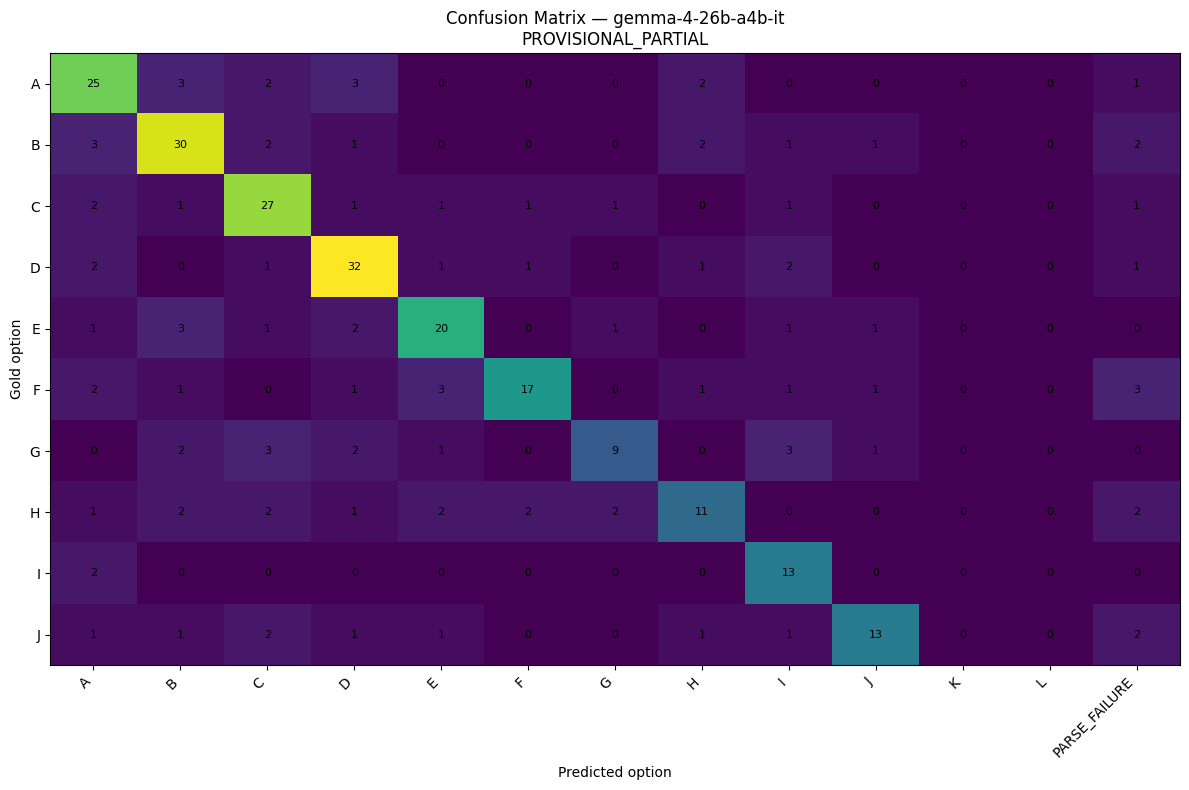

In [23]:
if n_valid:
    max_choices_observed = int(results['n_options'].max())
    observed_choice_labels = choice_letters(max_choices_observed)
    labels = observed_choice_labels + ['PARSE_FAILURE']

    cm = confusion_matrix(yt, yp, labels=labels)

    # Gold labels occupy only rows actually present in the dataset.
    gold_labels_present = [
        label for label in observed_choice_labels
        if label in set(yt)
    ]
    row_indices = [labels.index(label) for label in gold_labels_present]
    cm_display = cm[row_indices, :]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(cm_display, aspect='auto')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(gold_labels_present)))
    ax.set_yticklabels(gold_labels_present)

    ax.set_xlabel('Predicted option')
    ax.set_ylabel('Gold option')
    ax.set_title(f'Confusion Matrix — {MODEL}\n{status}')

    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            ax.text(
                j, i, str(cm_display[i, j]),
                ha='center', va='center', fontsize=8
            )

    fig.tight_layout()
    fig.savefig(
        PLOTS_DIR / 'confusion_matrix.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()


# 19. Runtime, throughput, token cost, output-length and retry metrics


In [24]:
def num(s): return pd.to_numeric(s,errors='coerce')
sessions=read_jsonl(SESSIONS); events=read_jsonl(EVENTS); active_s=sum(float(x.get('session_active_duration_s') or 0) for x in sessions); eff={}
if n_valid:
    successful_latency=num(results['latency_s']).dropna(); sample_wall=num(results['sample_total_wall_s']).dropna(); pt=num(results['prompt_tokens']).dropna(); ct=num(results['completion_tokens']).dropna(); rt=num(results['reasoning_tokens']).dropna(); tt=num(results['total_tokens']).dropna()
    total_pt=float(pt.sum()) if len(pt) else np.nan; total_ct=float(ct.sum()) if len(ct) else np.nan; total_rt=float(rt.sum()) if len(rt) else np.nan; total_tt=float(tt.sum()) if len(tt) else np.nan
    attempt_elapsed=[float(e['elapsed_s']) for e in events if e.get('elapsed_s') is not None and e.get('event')!='retry_backoff']; backoffs=[float(e['backoff_s']) for e in events if e.get('event')=='retry_backoff' and e.get('backoff_s') is not None]; total_success=float(successful_latency.sum())
    eff={'total_active_kaggle_session_s':active_s,'total_active_kaggle_session_h':active_s/3600,'calls_per_min_active_session':60*n_valid/active_s if active_s else np.nan,
      'total_successful_api_latency_s':total_success,'mean_successful_api_latency_s':float(successful_latency.mean()),'median_successful_api_latency_s':float(successful_latency.median()),'p95_successful_api_latency_s':float(successful_latency.quantile(.95)),
      'total_sample_wall_s':float(sample_wall.sum()),'mean_sample_wall_s':float(sample_wall.mean()),'median_sample_wall_s':float(sample_wall.median()),'p95_sample_wall_s':float(sample_wall.quantile(.95)),
      'total_logged_api_attempt_elapsed_s':float(sum(attempt_elapsed)),'total_logged_retry_backoff_s':float(sum(backoffs)),'logged_retry_backoff_events':len(backoffs),
      'total_prompt_tokens':total_pt,'mean_prompt_tokens':float(pt.mean()) if len(pt) else np.nan,'total_completion_tokens':total_ct,'mean_completion_tokens':float(ct.mean()) if len(ct) else np.nan,
      'total_provider_reasoning_tokens_if_exposed':total_rt,'mean_provider_reasoning_tokens_if_exposed':float(rt.mean()) if len(rt) else np.nan,'total_tokens':total_tt,'mean_total_tokens':float(tt.mean()) if len(tt) else np.nan,
      'completion_tokens_per_successful_api_second':total_ct/total_success if total_success>0 and not math.isnan(total_ct) else np.nan,'total_visible_output_chars':int(results['visible_output_chars'].sum()),'mean_visible_output_chars':float(results['visible_output_chars'].mean()),
      'total_visible_output_words':int(results['visible_output_words'].sum()),'mean_visible_output_words':float(results['visible_output_words'].mean()),'total_provider_reasoning_chars_if_exposed':int(results['reasoning_chars'].sum()),
      'mean_provider_reasoning_chars_if_exposed':float(results['reasoning_chars'].mean()),'total_combined_output_chars':int(results['combined_output_chars'].sum()),'mean_combined_output_chars':float(results['combined_output_chars'].mean()),
      'responses_with_more_than_one_attempt_in_successful_pass':int((results['attempts']>1).sum()),'logged_retry_events':sum(1 for e in events if e.get('will_retry') is True and e.get('event')!='retry_backoff'),
      'logged_pass_exhaustions':sum(1 for e in events if e.get('event')=='pass_exhausted_without_valid_response'),'logged_http_429_events':sum(1 for e in events if e.get('http_status')==429),
      'primary_answer_parse_failures':int((~results['answer_parse_success'].astype(bool)).sum()),'exact_format_failures':int((~results['exact_format_compliant'].astype(bool)).sum()),'primary_diagnostic_disagreements':int(results['primary_diagnostic_disagreement'].astype(bool).sum()),'truncated_responses':int(results['truncated'].astype(bool).sum())}
    if PRICE_INPUT_PER_1M_USD is not None and PRICE_OUTPUT_PER_1M_USD is not None: eff['estimated_monetary_api_cost_usd']=total_pt/1e6*PRICE_INPUT_PER_1M_USD+total_ct/1e6*PRICE_OUTPUT_PER_1M_USD
    else: eff['estimated_monetary_api_cost_usd']=None
    display(pd.DataFrame([eff]).T.rename(columns={0:'value'}).round(4))


,value
total_active_kaggle_session_s,14725.293724
total_active_kaggle_session_h,4.090359
calls_per_min_active_session,1.218312
total_successful_api_latency_s,8831.122657
mean_successful_api_latency_s,29.535527
median_successful_api_latency_s,14.696098
p95_successful_api_latency_s,146.234776
total_sample_wall_s,11519.855744
mean_sample_wall_s,38.527946
median_sample_wall_s,15.672829


# 20. Latency and completion-token distributions


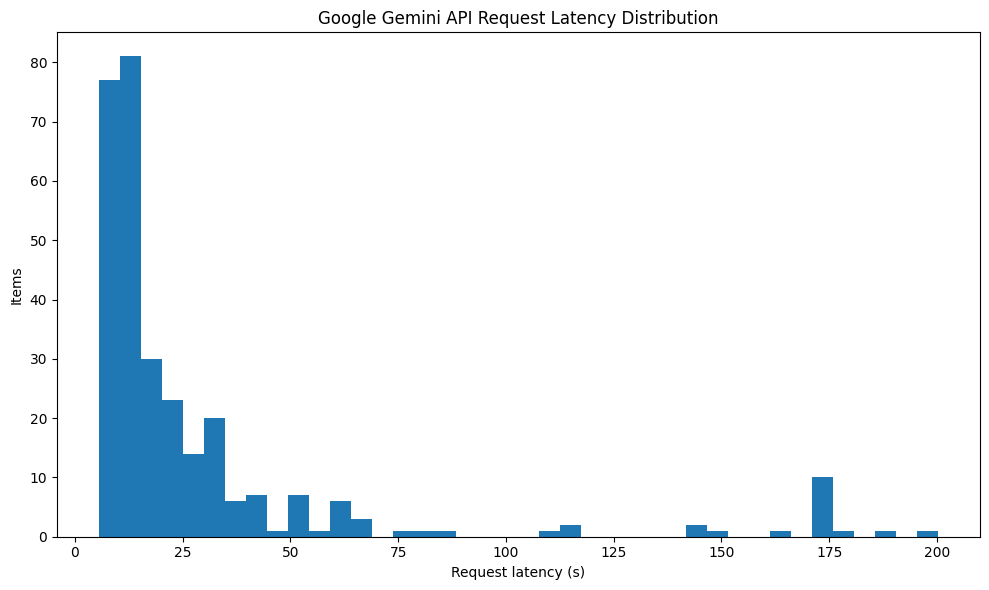

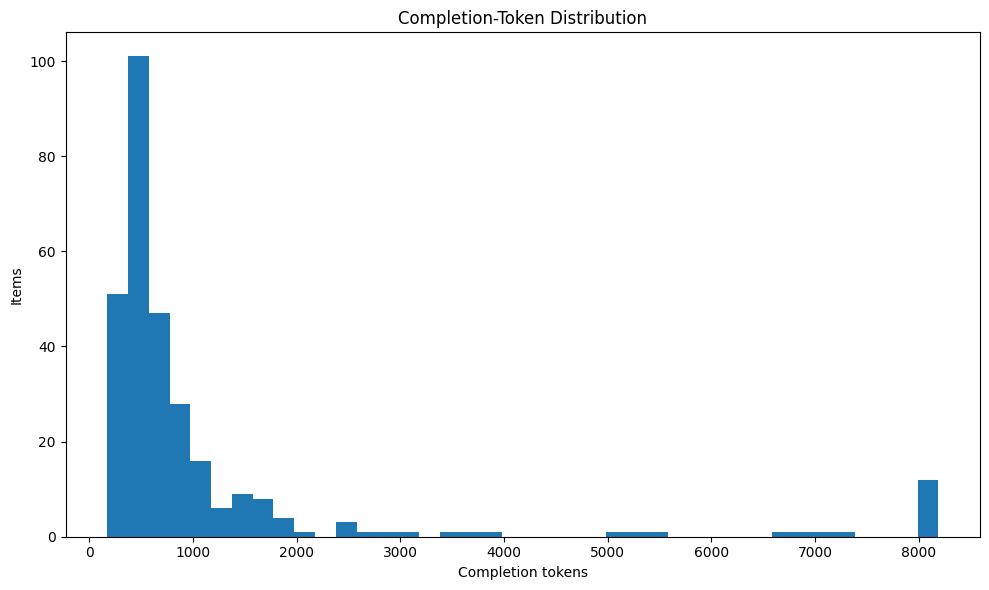

In [25]:
if n_valid:
    fig,ax=plt.subplots(figsize=(10,6)); ax.hist(num(results['latency_s']).dropna(),bins=40); ax.set_xlabel('Request latency (s)'); ax.set_ylabel('Items'); ax.set_title('Google Gemini API Request Latency Distribution'); fig.tight_layout(); fig.savefig(PLOTS_DIR/'latency_distribution.png',dpi=180,bbox_inches='tight'); plt.show()
if n_valid and results['completion_tokens'].notna().any():
    fig,ax=plt.subplots(figsize=(10,6)); ax.hist(num(results['completion_tokens']).dropna(),bins=40); ax.set_xlabel('Completion tokens'); ax.set_ylabel('Items'); ax.set_title('Completion-Token Distribution'); fig.tight_layout(); fig.savefig(PLOTS_DIR/'completion_tokens.png',dpi=180,bbox_inches='tight'); plt.show()


# 21. Subject, domain, difficulty, image-type and image-count analyses


In [26]:
DOMAIN={'Art and Design':['Art','Art_Theory','Design','Music'],'Business':['Accounting','Economics','Finance','Manage','Marketing'],
 'Science':['Biology','Chemistry','Geography','Math','Physics'],'Health and Medicine':['Basic_Medical_Science','Clinical_Medicine','Diagnostics_and_Laboratory_Medicine','Pharmacy','Public_Health'],
 'Humanities and Social Science':['History','Literature','Sociology','Psychology'],'Tech and Engineering':['Agriculture','Architecture_and_Engineering','Computer_Science','Electronics','Energy_and_Power','Materials','Mechanical_Engineering']}
S2D={s:d for d,ss in DOMAIN.items() for s in ss}
def group_acc(df,col): return df.groupby(col,dropna=False).agg(n=('sample_id','size'),correct=('answer_correct','sum'),accuracy=('answer_correct','mean'),mean_latency_s=('latency_s','mean'),mean_completion_tokens=('completion_tokens','mean')).reset_index()
if n_valid:
    results['domain']=results['subject'].map(S2D).fillna('Other/Unmapped')
    subject=group_acc(results,'subject'); domain=group_acc(results,'domain'); diff=group_acc(results,'topic_difficulty'); imgt=group_acc(results,'img_type'); imgc=group_acc(results,'image_count')
    subject.to_csv(SUBJECT_CSV,index=False); domain.to_csv(DOMAIN_CSV,index=False); diff.to_csv(DIFF_CSV,index=False); imgt.to_csv(IMGTYPE_CSV,index=False); imgc.to_csv(IMGCOUNT_CSV,index=False)
    print('Domain'); display(domain.round(4)); print('Difficulty'); display(diff.round(4)); print('Image count'); display(imgc.round(4)); print('Subject'); display(subject.round(4))


Domain


,domain,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Art and Design,40,24,0.6000,23.5982,889.4250
1,Business,49,40,0.8163,23.1005,884.5102
2,Health and Medicine,50,31,0.6200,16.5633,522.4600
3,Humanities and Social Science,40,25,0.6250,14.0706,489.4750
4,Science,50,30,0.6000,30.9333,1120.2000
5,Tech and Engineering,70,47,0.6714,54.5374,2410.0143


Difficulty


,topic_difficulty,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Easy,88,68,0.7727,23.5126,937.8864
1,Hard,88,52,0.5909,32.5894,1274.3182
2,Medium,123,77,0.6260,31.6597,1257.3740


Image count


,image_count,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,1,277,182,0.657,29.2854,1176.4224
1,2,12,12,1.000,30.3285,789.1667
2,3,1,1,1.000,16.7201,753.0000
3,4,5,1,0.200,12.7424,485.4000
4,5,4,1,0.250,68.6713,2703.0000


Subject


,subject,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Accounting,10,6,0.6,31.5827,1451.6000
1,Agriculture,10,8,0.8,17.4045,433.9000
2,Architecture_and_Engineering,10,7,0.7,86.9413,3880.2000
3,Art,10,5,0.5,16.7777,465.9000
4,Art_Theory,10,10,1.0,14.0534,426.7000
5,Basic_Medical_Science,10,6,0.6,10.5763,454.8000
6,Biology,10,4,0.4,27.1066,1073.6000
7,Chemistry,10,5,0.5,29.4805,855.2000
8,Clinical_Medicine,10,8,0.8,23.9302,462.2000
9,Computer_Science,10,7,0.7,38.7728,1695.3000


# 22. Answer-position bias diagnostics


,letter,gold_count,predicted_count
0,A,36,39
1,B,42,43
2,C,36,40
3,D,41,44
4,E,30,29
5,F,30,21
6,G,21,13
7,H,25,18
8,I,15,23
9,J,23,17


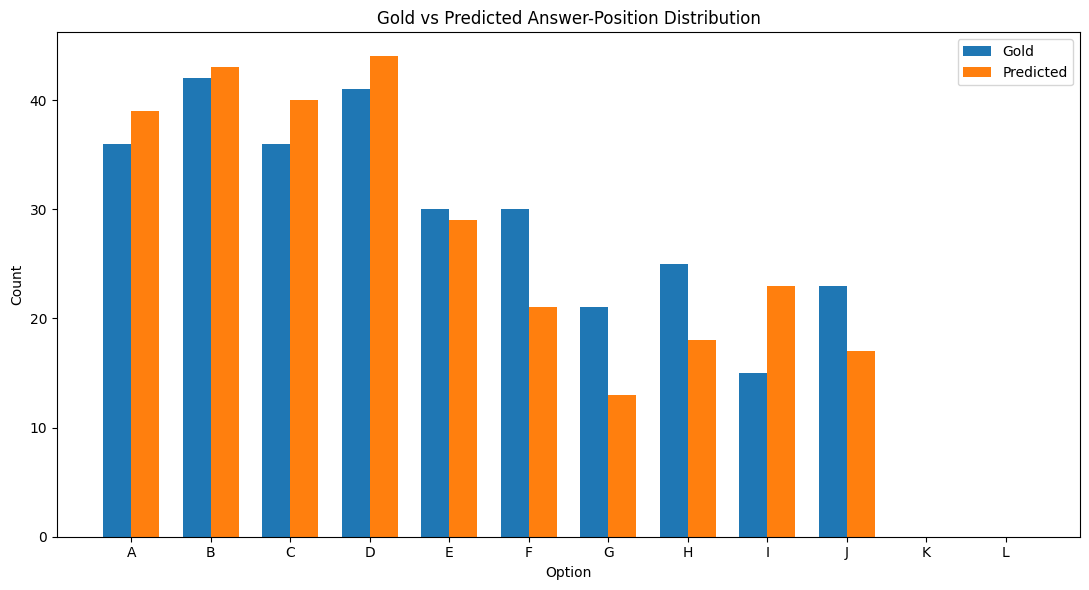

In [27]:
if n_valid:
    position_labels = choice_letters(int(results['n_options'].max()))

    g = results['gold_answer'].value_counts().reindex(position_labels, fill_value=0)
    p = results['answer_prediction'].value_counts().reindex(position_labels, fill_value=0)

    pos = pd.DataFrame({
        'letter': position_labels,
        'gold_count': g.values,
        'predicted_count': p.values,
    })
    display(pos)

    x = np.arange(len(position_labels))
    w = .35
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - w/2, pos['gold_count'], w, label='Gold')
    ax.bar(x + w/2, pos['predicted_count'], w, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(position_labels)
    ax.set_xlabel('Option')
    ax.set_ylabel('Count')
    ax.set_title('Gold vs Predicted Answer-Position Distribution')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR/'answer_positions.png', dpi=180, bbox_inches='tight')
    plt.show()


# 23. Consolidated paper-ready summary


In [28]:
summary = {
    'analysis_status': status,
    'complete': complete,
    'experiment_id': EXPERIMENT_ID,
    'experiment_signature': EXPERIMENT_SIGNATURE,
    'protocol_version': PROTOCOL_VERSION,
    'parser_version': PARSER_VERSION,
    'parser_spec_sha256': PARSER_SPEC_SHA256,
    'scoring_signature': SCORING_SIGNATURE,
    'evaluation_cohort_id': EVALUATION_COHORT_ID,
    'model': MODEL,
    'provider': PROVIDER,
    'api_method': API_METHOD,
    'dataset_revision': DATASET_REVISION,
    'n_dataset': n_total,
    'n_valid': n_valid,
    'n_missing': n_total - n_valid,
    'coverage': coverage,
    'prompt_id': PROMPT_ID,
    'prompt_family': PROMPT_FAMILY,
    'prompt_suffix_sha256': PROMPT_SUFFIX_SHA,
    'prompt_template_sha256': PROMPT_TEMPLATE_SHA,
    'question_prefix_added': False,
    'selection_protocol': SELECTION_PROTOCOL_NAME,
    'selected_ids_sha256': SELECTED_IDS_CANONICAL_SHA256,
    'source_rows': len(source_ds),
    'classification': classification,
    'efficiency': eff,
    'primary_answer_parse_rate': None if pd.isna(parse_rate) else float(parse_rate),
    'exact_format_compliance_rate': None if pd.isna(fmt) else float(fmt),
    'primary_diagnostic_disagreement_rate': (
        None if pd.isna(diagnostic_disagreement_rate)
        else float(diagnostic_disagreement_rate)
    ),
    'truncation_rate': None if pd.isna(trunc) else float(trunc),
}
SUMMARY_JSON.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8'
)
flat_summary = {
    'analysis_status': status,
    'complete': complete,
    'experiment_signature': EXPERIMENT_SIGNATURE,
    'protocol_version': PROTOCOL_VERSION,
    'parser_version': PARSER_VERSION,
    'parser_spec_sha256': PARSER_SPEC_SHA256,
    'scoring_signature': SCORING_SIGNATURE,
    'model': MODEL,
    'provider': PROVIDER,
    'api_method': API_METHOD,
    'dataset_revision': DATASET_REVISION,
    'n_dataset': n_total,
    'n_valid': n_valid,
    'n_missing': n_total - n_valid,
    'coverage': coverage,
    **classification,
    **eff,
}
pd.DataFrame([flat_summary]).to_csv(SUMMARY_CSV, index=False)
display(pd.DataFrame([flat_summary]).T.rename(columns={0: 'value'}))


,value
analysis_status,PROVISIONAL_PARTIAL
complete,False
experiment_signature,206752a37b93587ae4f31ee8c3b22c14f8b03727e81db3...
protocol_version,P0_WITHOUT_BRIEFLY_GEMMA4-26B-A4B-IT_EVAL300_V...
parser_version,deterministic_final_line_answer_v1
...,...
primary_answer_parse_failures,12
exact_format_failures,17
primary_diagnostic_disagreements,0
truncated_responses,12


# 24. Professional qualitative audit viewer


In [29]:
def br(x): return html.escape(str(x or '')).replace('\n','<br>')
if GENERATE_HTML_AUDIT and n_valid:
    cards=[]
    for _,r in results.sort_values('execution_order').iterrows():
        imgs=''.join(f'<img src="{html.escape(p)}" style="max-width:420px;max-height:320px;margin:6px;border:1px solid #ddd">' for p in str(r['image_files']).split(';') if p)
        opts=json.loads(r['options_json']); ol='<ol type="A">'+''.join(f'<li>{html.escape(str(o))}</li>' for o in opts)+'</ol>'
        verdict='CORRECT' if bool(r['answer_correct']) else 'WRONG'
        cards.append(f"""<section style="border:1px solid #bbb;padding:16px;margin:18px 0"><h2>{html.escape(str(r['sample_id']))} — {verdict}</h2>
        <p><b>Subject:</b> {html.escape(str(r['subject']))}<br><b>Primary answer prediction:</b> {html.escape(str(r['answer_prediction']))}<br><b>Primary parse method:</b> {html.escape(str(r['answer_parse_method']))}<br><b>Exact requested format:</b> {html.escape(str(bool(r['exact_format_compliant'])))}<br><b>Gold:</b> {html.escape(str(r['gold_answer']))} — {html.escape(str(r['gold_option_text']))}</p>
        <div>{imgs}</div><h3>Question</h3><p>{br(r['question'])}</p><h3>Options</h3>{ol}<h3>Visible model response</h3><div style="background:#f6f6f6;padding:10px">{br(r['visible_response'])}</div>
        <h3>Model-provided reasoning field</h3><div style="background:#fafafa;padding:10px">{br(r['reasoning_content'])}</div><h3>Gold explanation — intentionally excluded from inference records</h3><div style="background:#fff9e8;padding:10px">{br(r['gold_explanation'])}</div></section>""")
    doc=f'<!doctype html><html><head><meta charset="utf-8"><title>{EXPERIMENT_ID}</title></head><body style="font-family:Arial;max-width:1200px;margin:auto;padding:20px"><h1>{EXPERIMENT_ID}</h1><p><b>Status:</b> {status}; {n_valid}/{n_total}</p>'+''.join(cards)+'</body></html>'
    AUDIT_HTML.write_text(doc,encoding='utf-8'); print('Saved',AUDIT_HTML)


Saved /kaggle/working/gemma4-26b-a4b-it_eval300_without_briefly_v2/audit_viewer.html


# 25. README_RESULTS.md and final completion gate


In [30]:
def pct(x):
    return "N/A" if x is None or pd.isna(x) else f"{100*float(x):.2f}%"

readme = f"""# {EXPERIMENT_ID}

## Status
**{status}** — {n_valid}/{n_total} valid model responses.

## Dataset
- Source: `{DATASET_REPO}` / `{DATASET_CONFIG}` / `{DATASET_SPLIT}`
- Revision: `{DATASET_REVISION}`
- Full source rows: `{len(source_ds)}`
- Selected IDs SHA256: `{SELECTED_IDS_CANONICAL_SHA256}`
- Selected rows: `{len(ds)}`
- Subjects: `{len(selected_subject_counts)}`
- Subject counts: `{dict(sorted(selected_subject_counts.items()))}`
- Execution order SHA256: `{ORDER_SHA}`

## Google-hosted Gemma 4 model
- Model: `{MODEL}`
- Provider: `{PROVIDER}`
- Endpoint: `{INVOKE_URL}`
- API method: `{API_METHOD}`
- Key source: `{GOOGLE_API_KEY_SOURCE}`
- Key value archived: `False`

## Generation
- Temperature: `{TEMPERATURE}`
- Top-p sent: `False`
- Top-k sent: `False`
- Max output tokens: `{MAX_TOKENS}`
- Seed: `{API_SEED}`
- Stream: `{STREAM}`
- thinking_level: `minimal`
- reasoning_budget sent: `False`
- Context policy: `{CTX_SIZE_POLICY}`

## Input
- images first in numbered-marker occurrence order
- repeated image references repeat the image block
- numbered `<image n>` markers normalized to `<image>`
- lossless PNG base64 inlineData
- no system message
- no `Question:` prefix
- no demonstrations
- no gold answer
- no source explanation

## Scheduling
- main timeout: `{REQUEST_TIMEOUT_S}` s
- deferred timeout: `{DEFERRED_REQUEST_TIMEOUT_S}` s
- main attempts: `{MAX_ATTEMPTS}`
- deferred transient attempts: `{DEFERRED_MAX_ATTEMPTS}`
- deferred retry passes: `{DEFERRED_RETRY_PASSES}`
- timeouts are deferred immediately to the long-timeout pass
- unexpected provider-native thought output is deferred rather than stopping the run
- inter-request delay: `{INTER_REQUEST_DELAY_S}` s
- async 202 polling: not used by Google `generateContent`
- quota stop after exhausted 429s: `{MAX_CONSECUTIVE_EXHAUSTED_429}`
- exact-signature prior checkpoints are validated record-by-record before resume
- compatible nonbrief First50 successes may be migrated only after full item-level equivalence checks
- only IDs without a valid provider response are sent again
- valid parse failures and truncated generations are retained and scored, not regenerated

## P0 prompt suffix
```text
{PROMPT_SUFFIX}
```

Prompt suffix SHA256: `{PROMPT_SUFFIX_SHA}`
Prompt template SHA256: `{PROMPT_TEMPLATE_SHA}`

## Frozen scoring
- Parser version: `{PARSER_VERSION}`
- Parser specification SHA256: `{PARSER_SPEC_SHA256}`
- Scoring signature: `{SCORING_SIGNATURE}`
- Primary: deterministic, gold-blind last-non-empty-line answer accuracy
- Accepted primary wrappers: `Answer: B`, `Answer: $B`, `Answer: $B$`, `Answer: (B)`; optional terminal period
- `$LETTER` is treated as a placeholder; exact instantiated compliance is `Answer: B`
- No random fallback; no reasoning-body scan for the primary outcome
- Truncated responses are unparsed and incorrect
- All checkpointed raw responses are reparsed under the frozen parser version

## Headline results
- Primary answer accuracy: {pct(classification.get('primary_answer_accuracy'))}
- Macro F1: {classification.get('macro_f1','N/A')}
- Weighted F1: {classification.get('weighted_f1','N/A')}
- Primary answer parse rate: {pct(parse_rate)}
- Exact requested-format compliance: {pct(fmt)}
- Diagnostic MMMU-Pro-style accuracy (no random fallback): {pct(classification.get('diagnostic_mmmupro_style_accuracy_no_random_fallback'))}
- Primary/diagnostic disagreement rate: {pct(diagnostic_disagreement_rate)}
- Incomplete/truncation rate: {pct(trunc)}

## Error-analysis export
- File: `{ERROR_ANALYSIS_CSV.name}`
- Contents: all primary answer errors, including parse failures and truncated generations
- Formatting-only deviations are excluded from content-error annotation and retained in `{PARSER_AUDIT_CSV.name}`
- Annotation target: error type only

Final headline metrics are reportable only when status is `COMPLETE_EVAL300` and
all 300 selected IDs have one validated provider response.
"""

README.write_text(readme, encoding="utf-8")
print(readme)


# MMMUPro-Eval300__Gemma4-26B-A4B-IT__P0-ExplanationBaseline-WithoutBriefly__GoogleGeminiAPIFreeTier__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temp0__Seed42__MAX8192

## Status
**PROVISIONAL_PARTIAL** — 299/300 valid model responses.

## Dataset
- Source: `MMMU/MMMU_Pro` / `standard (10 options)` / `test`
- Revision: `563f3e84bb3b90893083a1f039cfa13077f2302b`
- Full source rows: `1730`
- Selected IDs SHA256: `db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3`
- Selected rows: `300`
- Subjects: `30`
- Subject counts: `{'Accounting': 10, 'Agriculture': 10, 'Architecture_and_Engineering': 10, 'Art': 10, 'Art_Theory': 10, 'Basic_Medical_Science': 10, 'Biology': 10, 'Chemistry': 10, 'Clinical_Medicine': 10, 'Computer_Science': 10, 'Design': 10, 'Diagnostics_and_Laboratory_Medicine': 10, 'Economics': 10, 'Electronics': 10, 'Energy_and_Power': 10, 'Finance': 10, 'Geography': 10, 'History': 10, 'Literature': 10, 'Manage': 10, 'Marketing': 10, 'Materials': 10, 'Math':

# 27. Suggested Methods wording for the production Eval300 experiment

> **Gemma 4 26B A4B IT Eval300 explanation baseline.**
> We evaluated the Google-hosted `gemma-4-26b-a4b-it` endpoint through the Gemini
> Developer API on all 300 items of the frozen, subject-balanced MMMU-Pro
> selection. The ordered ID list had canonical SHA-256
> `db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3`
> and contained 10 items from each of 30 subjects.
>
> Images were supplied before text in numbered-marker occurrence order.
> Repeated references repeated the corresponding image block, and numbered
> markers were normalized to `<image>`. No `Question:` prefix, demonstrations,
> gold answer, or reference explanation was supplied.
>
> Model and generation settings were identical across conditions:
> `temperature=0.0`, `seed=42`, and `maxOutputTokens=8192`; `topP` and `topK`
> were omitted, and Gemma 4 provider-native thinking was set to
> `thinkingLevel="minimal"`. Requests used the non-streaming `generateContent`
> endpoint.
>
> The final prompt instructions in this condition were:
> `Think step by step before answering.`  
> `Explain your reasoning before answering.`
>
> Main-pass requests used a 1,800-second timeout. Per-item failures were
> retained and retried after the main pass with a 7,200-second timeout.
> Compatible prior Kaggle outputs were resumed only after exact experiment-
> signature and record-level validation; only IDs without a valid provider
> response were sent again. Valid parse failures and length-limited responses
> were retained as model outcomes rather than selectively regenerated.
> Earlier nonbrief First50 responses, when supplied, were migrated only after
> exact equivalence checks for the item prompt, image hashes/order, model,
> and decoding configuration. Parser-derived checkpoint fields were not
> trusted; every stored raw response was reparsed under the same frozen
> parser version.
>
> The primary outcome was deterministic final-line answer accuracy. The
> parser inspected only the last non-empty line and accepted the finite,
> pre-specified forms `Answer: B`, `Answer: $B`, `Answer: $B$`, and
> `Answer: (B)` (optionally followed by a period), provided that the letter
> belonged to the row's available choices. It neither inspected the
> reasoning body nor used a guessing fallback. Exact compliance with the
> instantiated requested form (for example, `Answer: B`) was reported as a
> separate outcome; `$LETTER` was treated as a placeholder.
> Unparseable and truncated responses were scored as incorrect and retained
> in the denominator. A deterministic MMMU-Pro-style heuristic was reported
> only as a sensitivity diagnostic and used no random fallback.
